# `theta_full` vs `theta_incomplete_defaults` — natural kinetic-model review

This notebook audits one frozen reconstruction error in the **central kinetic model only**.
It performs no fitting, no optimization and no CO2-layer calculation. The 11 re-estimated
natural parameters are identical in both vectors; only `sN`, `qXG`, `qXF`, `sG`, `sF` and
`m0` differ.

Two analyses are kept strictly separate:

1. **Historical calibration replay — not a holdout:** LAB004–LAB012, including LAB009.
2. **External kinetic holdout:** LAB013–LAB015, on their common sample-1 proxy clock.

Labels are deliberately explicit throughout: `theta_full` and
`theta_incomplete_defaults`.

In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
ROOT = next(path for path in candidates if (path / "fermentation_model").exists())
FM = ROOT / "fermentation_model"
if str(FM) not in sys.path:
    sys.path.insert(0, str(FM))

from shared import run_new_must_glycerol_estimability_doe as kinetic
from laboratory_2026 import run_estimability_historical_by_medium as historical

NOTEBOOK_DIR = FM / "laboratory_2026" / "notebooks"
RESULTS_DIR = FM / "laboratory_2026" / "results" / "theta_full_vs_incomplete_defaults_natural_review"
FIGURE_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

FULL_THETA_PATH = FM / "laboratory_2026" / "results" / "estimability_historical_natural" / "theta_natural_full.csv"
PARTIAL_THETA_PATH = FM / "laboratory_2026" / "results" / "estimability_historical_natural" / "theta.csv"
MULTISTART_PATH = FM / "shared" / "results" / "new_must_glycerol_overnight_validation" / "theta_multistart_07.csv"
ZENTENO_PDF_PATH = FM / "context" / "Zenteno_2010.pdf"
ZENTENO_CODE_PATH = FM / "context" / "Zenteno_Model_2020_Full.m"
MODEL_CODE_PATH = FM / "shared" / "run_new_must_glycerol_estimability_doe.py"

required = [FULL_THETA_PATH, PARTIAL_THETA_PATH, MULTISTART_PATH, ZENTENO_PDF_PATH, ZENTENO_CODE_PATH, MODEL_CODE_PATH]
assert all(path.exists() for path in required), [str(path) for path in required if not path.exists()]

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 180, "font.size": 9.5, "axes.titlesize": 10.5})

STATE_UNITS = {
    "X": r"kg m$^{-3}$ (= g L$^{-1}$)",
    "Xd": r"kg m$^{-3}$ (= g L$^{-1}$)",
    "N": r"kg m$^{-3}$ (= g L$^{-1}$)",
    "G": r"kg m$^{-3}$ (= g L$^{-1}$)",
    "F": r"kg m$^{-3}$ (= g L$^{-1}$)",
    "E": r"kg m$^{-3}$ (= g L$^{-1}$)",
    "Gly": r"kg m$^{-3}$ (= g L$^{-1}$)",
}
COLORS = {"theta_full": "#1f77b4", "theta_incomplete_defaults": "#d95f02"}
STYLES = {"theta_full": "-", "theta_incomplete_defaults": "--"}
print("Repository root:", ROOT)
print("Results:", RESULTS_DIR.relative_to(ROOT))

Repository root: D:\claud\Desktop\Universidad\Memoria\Model\pyomo-doe
Results: fermentation_model\laboratory_2026\results\theta_full_vs_incomplete_defaults_natural_review


## Parameter reconstruction and provenance audit

`theta_full` is loaded only from the canonical 17-row artifact. The incomplete vector is
reconstructed by copying it and replacing exactly six entries with `DEFAULT_THETA`.
Consequently this is **not** a comparison of two independently calibrated models.

For the Zenteno review, a transformed parameter is called literature-supported only when
its algebraic definition and units match the current equations. A matching number alone
is insufficient.

In [2]:
full_frame = pd.read_csv(FULL_THETA_PATH)
theta_full = full_frame.set_index("parameter")["theta"].astype(float).to_dict()
assert tuple(theta_full) == tuple(kinetic.FULL17)
assert len(theta_full) == 17

reestimated = tuple(kinetic.REDUCED11)
inherited = ("sN", "qXG", "qXF", "sG", "sF", "m0")
assert set(reestimated).isdisjoint(inherited)
assert set(reestimated) | set(inherited) == set(kinetic.FULL17)

expected_defaults = {
    "sN": 18.0,
    "qXG": 0.1125,
    "qXF": 0.1125,
    "sG": 0.03,
    "sF": 0.03,
    "m0": 0.01,
}
for name, value in expected_defaults.items():
    assert np.isclose(float(kinetic.DEFAULT_THETA[name]), value)

theta_incomplete_defaults = dict(theta_full)
theta_incomplete_defaults.update(expected_defaults)
theta_sets = {
    "theta_full": theta_full,
    "theta_incomplete_defaults": theta_incomplete_defaults,
}
differences = {
    name for name in kinetic.FULL17
    if not np.isclose(theta_full[name], theta_incomplete_defaults[name], rtol=0.0, atol=1e-15)
}
assert differences == set(inherited)

multistart = pd.read_csv(MULTISTART_PATH, index_col=0).iloc[:, 0].astype(float).to_dict()
for name in inherited:
    assert np.isclose(theta_full[name], multistart[name])
partial = pd.read_csv(PARTIAL_THETA_PATH)
assert set(reestimated).issubset(set(partial["parameter"]))
for name in reestimated:
    partial_value = float(partial.loc[partial["parameter"].eq(name), "theta"].iloc[0])
    assert np.isclose(theta_full[name], partial_value)

comparison_rows = []
for name in kinetic.FULL17:
    comparison_rows.append({
        "parameter": name,
        "theta_full": theta_full[name],
        "theta_incomplete_defaults": theta_incomplete_defaults[name],
        "differs": name in inherited,
        "theta_full_source": (
            "estimability_historical_natural/theta.csv (re-estimated natural calibration)"
            if name in reestimated else
            "new_must_glycerol_overnight_validation/theta_multistart_07.csv (fixed during natural calibration)"
        ),
        "theta_incomplete_defaults_source": (
            "same re-estimated natural-calibration value" if name in reestimated else
            "DEFAULT_THETA fallback"
        ),
    })
parameters_comparison = pd.DataFrame(comparison_rows)
display(parameters_comparison)

,parameter,theta_full,theta_incomplete_defaults,differs,theta_full_source,theta_incomplete_defaults_source
0,mu0,0.078728,0.078728,False,estimability_historical_natural/theta.csv (re-...,same re-estimated natural-calibration value
1,sN,8.751446,18.000000,True,new_must_glycerol_overnight_validation/theta_m...,DEFAULT_THETA fallback
2,qN,0.021080,0.021080,False,estimability_historical_natural/theta.csv (re-...,same re-estimated natural-calibration value
3,qXG,0.081491,0.112500,True,new_must_glycerol_overnight_validation/theta_m...,DEFAULT_THETA fallback
4,qXF,0.070933,0.112500,True,new_must_glycerol_overnight_validation/theta_m...,DEFAULT_THETA fallback
5,betaG0,0.428878,0.428878,False,estimability_historical_natural/theta.csv (re-...,same re-estimated natural-calibration value
6,sG,0.097455,0.030000,True,new_must_glycerol_overnight_validation/theta_m...,DEFAULT_THETA fallback
7,betaF0,3.440399,3.440399,False,estimability_historical_natural/theta.csv (re-...,same re-estimated natural-calibration value
8,sF,0.178295,0.030000,True,new_must_glycerol_overnight_validation/theta_m...,DEFAULT_THETA fallback
9,qEG,1.712807,1.712807,False,estimability_historical_natural/theta.csv (re-...,same re-estimated natural-calibration value


In [3]:
definitions = {
    "mu0": ("reference maximum specific growth rate", r"h$^{-1}$"),
    "sN": (r"nitrogen saturation reparameterization: $s_N=\mu_0/K_{N0}$", r"m$^3$ kgN$^{-1}$ h$^{-1}$"),
    "qN": (r"nitrogen consumption coefficient: $q_N=\mu_0/Y_{X/N}$", "kgN kgBio$^{-1}$ h$^{-1}$"),
    "qXG": (r"growth-associated glucose consumption: $q_{XG}=\mu_0/Y_{X/G}$", "kgG kgBio$^{-1}$ h$^{-1}$"),
    "qXF": (r"growth-associated fructose consumption: $q_{XF}=\mu_0/Y_{X/F}$", "kgF kgBio$^{-1}$ h$^{-1}$"),
    "betaG0": ("reference ethanol-production rate from glucose", "kgE kgBio$^{-1}$ h$^{-1}$"),
    "sG": (r"glucose saturation reparameterization: $s_G=\beta_{G0}/K_{G0}$", "m$^3$ kgE kgBio$^{-1}$ kgG$^{-1}$ h$^{-1}$"),
    "betaF0": ("reference ethanol-production rate from fructose", "kgE kgBio$^{-1}$ h$^{-1}$"),
    "sF": (r"fructose saturation reparameterization: $s_F=\beta_{F0}/K_{F0}$", "m$^3$ kgE kgBio$^{-1}$ kgF$^{-1}$ h$^{-1}$"),
    "qEG": (r"fermentative glucose consumption: $q_{EG}=\beta_{G0}/Y_{E/G}$", "kgG kgBio$^{-1}$ h$^{-1}$"),
    "qEF": (r"fermentative fructose consumption: $q_{EF}=\beta_{F0}/Y_{E/F}$", "kgF kgBio$^{-1}$ h$^{-1}$"),
    "iG": (r"glucose inhibition inverse constant: $i_G=1/K_{IG0}$", "m$^3$ kgG$^{-1}$"),
    "iE": (r"ethanol inhibition inverse constant: $i_E=1/K_{IE0}$", "m$^3$ kgE$^{-1}$"),
    "Kd0": ("reference specific death rate", r"h$^{-1}$"),
    "m0": ("reference cell-maintenance sugar-consumption coefficient", "kgS kgBio$^{-1}$ h$^{-1}$"),
    "gammaG0": ("glycerol-production coefficient coupled to glucose fermentation", "kgGly kgBio$^{-1}$ h$^{-1}$"),
    "gammaF0": ("glycerol-production coefficient coupled to fructose fermentation", "kgGly kgBio$^{-1}$ h$^{-1}$"),
}
zenteno = {
    "mu0": (True, True, "mu0 = 0.18 h^-1", "Table 2; direct parameter"),
    "sN": (False, True, "0.18 / 0.01 = 18.0", "derived from mu0 and KN0 using the implemented sN=mu0/KN0"),
    "qN": (False, True, "0.18 / 19.69 = 0.0091417", "derived from mu0 and YX/N"),
    "qXG": (False, True, "0.18 / 1.60 = 0.1125", "derived from mu0 and YX/G"),
    "qXF": (False, True, "0.18 / 1.60 = 0.1125", "derived from mu0 and YX/F"),
    "betaG0": (True, True, "betaG0 = 0.225 kgE kgBio^-1 h^-1", "Table 2; direct parameter"),
    "sG": (False, True, "0.225 / 7.5 = 0.03", "derived from betaG0 and KG0 using the implemented sG=betaG0/KG0"),
    "betaF0": (True, True, "betaF0 = 0.225 kgE kgBio^-1 h^-1", "Table 2; direct parameter"),
    "sF": (False, True, "0.225 / 7.5 = 0.03", "derived from betaF0 and KF0 using the implemented sF=betaF0/KF0"),
    "qEG": (False, True, "0.225 / 0.49 = 0.459184", "derived from betaG0 and YE/G"),
    "qEF": (False, True, "0.225 / 0.49 = 0.459184", "derived from betaF0 and YE/F"),
    "iG": (False, True, "1 / KIG0; KIG0=S/4", "equivalent inverse-constant definition; no single fixed paper value"),
    "iE": (False, True, "1 / 40 = 0.025", "derived from KIE0"),
    "Kd0": (True, True, "Kd0 = 0.00044 h^-1", "Table 2; direct parameter"),
    "m0": (True, True, "m0 = 0.01 kgS kgBio^-1 h^-1", "Table 2; direct parameter, attributed there to Boulton 1979"),
    "gammaG0": (False, False, "not reported", "glycerol state is not present in the Zenteno central model"),
    "gammaF0": (False, False, "not reported", "glycerol state is not present in the Zenteno central model"),
}
provenance_rows = []
for name in kinetic.FULL17:
    direct, equivalent, paper_value, evidence = zenteno[name]
    is_inherited = name in inherited
    provenance_rows.append({
        "parameter": name,
        "theta_full": theta_full[name],
        "theta_incomplete_defaults": theta_incomplete_defaults[name],
        "definition": definitions[name][0],
        "units": definitions[name][1],
        "theta_full_provenance": parameters_comparison.set_index("parameter").loc[name, "theta_full_source"],
        "theta_full_classification": "calibración previa",
        "theta_incomplete_defaults_provenance": (
            evidence + "; serialized in DEFAULT_THETA as implementation fallback"
            if is_inherited else "same re-estimated natural-calibration value as theta_full"
        ),
        "theta_incomplete_defaults_classification": "literatura" if is_inherited else "calibración previa",
        "is_one_of_six_reconstruction_differences": is_inherited,
        "zenteno_direct_parameter_symbol": direct,
        "zenteno_equivalent_definition_and_units_verified": equivalent,
        "zenteno_reported_or_derived_value": paper_value,
        "zenteno_evidence": evidence,
        "zenteno_source": "Zenteno et al. (2010), equations 2, 6–11 and Table 2 (printed pp. 41, 45)",
    })
parameter_provenance = pd.DataFrame(provenance_rows)

six_provenance = parameter_provenance[parameter_provenance["is_one_of_six_reconstruction_differences"]]
assert six_provenance["zenteno_equivalent_definition_and_units_verified"].all()
assert six_provenance.loc[six_provenance["parameter"].eq("m0"), "zenteno_direct_parameter_symbol"].all()
assert not six_provenance.loc[~six_provenance["parameter"].eq("m0"), "zenteno_direct_parameter_symbol"].any()
display(six_provenance[[
    "parameter", "theta_full", "theta_incomplete_defaults", "definition", "units",
    "theta_full_provenance", "zenteno_direct_parameter_symbol",
    "zenteno_reported_or_derived_value", "zenteno_evidence"
]])

display(Markdown(
    "**Zenteno verdict.** All six fallback numbers are documentably supported by the "
    "Zenteno model after verifying definition and units. `m0=0.01` is printed directly; "
    "`sN`, `qXG`, `qXF`, `sG` and `sF` are current reparameterizations algebraically "
    "derived from the paper's `mu0`, saturation constants and yields. Their role as "
    "`DEFAULT_THETA` values is an implementation choice; their numerical origin is literature-based."
))

,parameter,theta_full,theta_incomplete_defaults,definition,units,theta_full_provenance,zenteno_direct_parameter_symbol,zenteno_reported_or_derived_value,zenteno_evidence
1,sN,8.751446,18.0000,nitrogen saturation reparameterization: $s_N=\...,m$^3$ kgN$^{-1}$ h$^{-1}$,new_must_glycerol_overnight_validation/theta_m...,False,0.18 / 0.01 = 18.0,derived from mu0 and KN0 using the implemented...
3,qXG,0.081491,0.1125,growth-associated glucose consumption: $q_{XG}...,kgG kgBio$^{-1}$ h$^{-1}$,new_must_glycerol_overnight_validation/theta_m...,False,0.18 / 1.60 = 0.1125,derived from mu0 and YX/G
4,qXF,0.070933,0.1125,growth-associated fructose consumption: $q_{XF...,kgF kgBio$^{-1}$ h$^{-1}$,new_must_glycerol_overnight_validation/theta_m...,False,0.18 / 1.60 = 0.1125,derived from mu0 and YX/F
6,sG,0.097455,0.0300,glucose saturation reparameterization: $s_G=\b...,m$^3$ kgE kgBio$^{-1}$ kgG$^{-1}$ h$^{-1}$,new_must_glycerol_overnight_validation/theta_m...,False,0.225 / 7.5 = 0.03,derived from betaG0 and KG0 using the implemen...
8,sF,0.178295,0.0300,fructose saturation reparameterization: $s_F=\...,m$^3$ kgE kgBio$^{-1}$ kgF$^{-1}$ h$^{-1}$,new_must_glycerol_overnight_validation/theta_m...,False,0.225 / 7.5 = 0.03,derived from betaF0 and KF0 using the implemen...
14,m0,0.018339,0.0100,reference cell-maintenance sugar-consumption c...,kgS kgBio$^{-1}$ h$^{-1}$,new_must_glycerol_overnight_validation/theta_m...,True,m0 = 0.01 kgS kgBio^-1 h^-1,"Table 2; direct parameter, attributed there to..."


**Zenteno verdict.** All six fallback numbers are documentably supported by the Zenteno model after verifying definition and units. `m0=0.01` is printed directly; `sN`, `qXG`, `qXF`, `sG` and `sF` are current reparameterizations algebraically derived from the paper's `mu0`, saturation constants and yields. Their role as `DEFAULT_THETA` values is an implementation choice; their numerical origin is literature-based.

## Historical calibration replay — not a holdout

**Historical calibration replay — NOT an external holdout.** LAB004–LAB012 were used to
calibrate the natural kinetic model. These figures and metrics do not evaluate
generalization. They only audit how the six-value reconstruction bug changes trajectories
on the calibration dataset itself.

Both theta vectors use the identical historical loader, observations, initial conditions,
measured-temperature augmentation, nutrient pulses, horizon, observation functions and
historical sigma definitions. LAB009 is included because it participated in this kinetic
calibration; its later exclusion applied to CO2-layer calibration, not to theta natural.

In [4]:
historical_data, historical_all, _co2_times_unused, historical_process = historical.make_medium_batches("natural")
expected_historical_labs = tuple(f"LAB{i:03d}" for i in range(4, 13))
historical_batches = [batch for batch in historical_all if batch.batch in expected_historical_labs]
assert tuple(batch.batch for batch in historical_batches) == expected_historical_labs
assert "LAB009" in expected_historical_labs

historical_input_rows = []
for batch in historical_batches:
    historical_input_rows.append({
        "batch": batch.batch,
        "role": "historical calibration replay; NOT holdout",
        "participated_in_natural_kinetic_calibration": True,
        "later_CO2_layer_status": "excluded from CO2 layer only" if batch.batch == "LAB009" else "not relevant here",
        "n_model_times": len(batch.time),
        "t_min_h": float(batch.time[0]),
        "t_max_h": float(batch.time[-1]),
        "temperature_min_c": float(np.min(batch.temperature_c)),
        "temperature_max_c": float(np.max(batch.temperature_c)),
        "N_pulses": ";".join(f"{t:g}h:{v:g}" for t, v in batch.pulses["N"]) or "none",
        **{f"{state}0": float(batch.initials[state]) for state in kinetic.STATE_NAMES},
        **{f"n_{state}": int(np.isfinite(batch.observations[state]).sum()) for state in kinetic.STATE_NAMES},
    })
historical_input_audit = pd.DataFrame(historical_input_rows)
display(historical_input_audit)

,batch,role,participated_in_natural_kinetic_calibration,later_CO2_layer_status,n_model_times,t_min_h,t_max_h,temperature_min_c,temperature_max_c,N_pulses,...,F0,E0,Gly0,n_X,n_Xd,n_N,n_G,n_F,n_E,n_Gly
0,LAB004,historical calibration replay; NOT holdout,True,not relevant here,89,0.0,163.0,17.7,21.4,68h:0.08,...,70.81,9.707652,0.99,12,12,13,13,13,5,13
1,LAB005,historical calibration replay; NOT holdout,True,not relevant here,89,0.0,163.0,18.0,21.4,68h:0.08,...,87.95,9.786576,1.09,12,12,13,13,13,5,13
2,LAB006,historical calibration replay; NOT holdout,True,not relevant here,114,0.0,211.0,16.0,18.4,99h:0.08,...,75.81,9.865500,1.17,14,14,15,15,15,5,15
3,LAB007,historical calibration replay; NOT holdout,True,not relevant here,82,0.0,160.0,17.4,21.1,65h:0.08,...,74.55,11.759676,0.89,13,13,13,13,13,6,13
4,LAB008,historical calibration replay; NOT holdout,True,not relevant here,82,0.0,160.0,17.4,21.1,65h:0.08,...,74.89,9.234108,0.85,13,13,13,13,13,6,13
5,LAB009,historical calibration replay; NOT holdout,True,excluded from CO2 layer only,82,0.0,160.0,17.6,22.1,41h:0.08,...,76.68,9.707652,0.75,12,12,12,12,12,5,12
6,LAB010,historical calibration replay; NOT holdout,True,not relevant here,101,0.0,187.0,14.9,16.5,79h:0.08,...,77.05,9.313032,1.25,9,9,4,4,4,4,4
7,LAB011,historical calibration replay; NOT holdout,True,not relevant here,87,0.0,163.0,14.9,21.4,72h:0.08,...,76.67,9.313032,1.25,7,7,4,4,4,4,4
8,LAB012,historical calibration replay; NOT holdout,True,not relevant here,88,0.0,163.0,15.0,21.2,72h:0.08,...,79.88,9.391956,1.27,8,8,4,4,4,4,4


In [5]:
def prediction_points(batches, theta_label, theta, scope, score_initial_anchors=True):
    rows, trajectories = [], {}
    for batch in batches:
        sim = kinetic.simulate(batch, theta, batch.time)
        assert sim is not None, f"Simulation failed: {theta_label}/{batch.batch}"
        trajectories[batch.batch] = sim
        for state in kinetic.STATE_NAMES:
            obs = np.asarray(batch.observations[state], dtype=float)
            mask = np.isfinite(obs)
            indices = np.flatnonzero(mask)
            if not len(indices):
                continue
            pred = sim.loc[batch.time, state].to_numpy(dtype=float)
            sigma = kinetic.sigma_for_state(state, obs[mask])
            for order, (idx, sig) in enumerate(zip(indices, sigma)):
                is_anchor = bool(np.isclose(batch.time[idx], batch.time[0]))
                rows.append({
                    "scope": scope, "theta": theta_label, "batch": batch.batch,
                    "state": state, "unit": STATE_UNITS[state], "time_h": float(batch.time[idx]),
                    "observed": float(obs[idx]), "predicted": float(pred[idx]), "sigma": float(sig),
                    "error_pred_minus_obs": float(pred[idx] - obs[idx]),
                    "initial_condition_anchor": is_anchor,
                    "is_first_observation": order == 0,
                    "is_last_observation": order == len(indices) - 1,
                    "used_in_score": bool(score_initial_anchors or not is_anchor),
                })
    return pd.DataFrame(rows), trajectories


def metrics_by_group(points, group_columns, endpoints=True):
    rows = []
    for keys, all_group in points.groupby(group_columns, sort=True):
        keys = keys if isinstance(keys, tuple) else (keys,)
        group = all_group[all_group["used_in_score"]].sort_values(["batch", "time_h"])
        if group.empty:
            continue
        obs = group["observed"].to_numpy(float)
        pred = group["predicted"].to_numpy(float)
        err = pred - obs
        sigma = group["sigma"].to_numpy(float)
        observed_range = float(np.ptp(obs))
        ss_tot = float(np.sum((obs - np.mean(obs)) ** 2))
        row = {name: value for name, value in zip(group_columns, keys)}
        row.update({
            "n_observations": len(group),
            "rmse": float(np.sqrt(np.mean(err ** 2))),
            "nrmse_observed_range": float(np.sqrt(np.mean(err ** 2)) / observed_range) if observed_range > 0 else np.nan,
            "bias_pred_minus_obs": float(np.mean(err)),
            "r2": 1.0 - float(np.sum(err ** 2)) / ss_tot if ss_tot > 0 else np.nan,
            "wsse": float(np.sum((err / sigma) ** 2)),
            "weighted_rmse_sigma_units": float(np.sqrt(np.mean((err / sigma) ** 2))),
        })
        if endpoints:
            ordered = all_group.sort_values(["batch", "time_h"])
            first, last = ordered.iloc[0], ordered.iloc[-1]
            row.update({
                "initial_time_h": float(first.time_h),
                "observed_initial": float(first.observed),
                "predicted_initial": float(first.predicted),
                "final_time_h": float(last.time_h),
                "observed_final": float(last.observed),
                "predicted_final": float(last.predicted),
            })
        rows.append(row)
    return pd.DataFrame(rows)


def normalized_aggregate(points, group_columns, state_batch_metrics=None):
    rows = []
    for keys, group in points[points["used_in_score"]].groupby(group_columns, sort=True):
        keys = keys if isinstance(keys, tuple) else (keys,)
        err_sigma = group["error_pred_minus_obs"].to_numpy(float) / group["sigma"].to_numpy(float)
        row = {name: value for name, value in zip(group_columns, keys)}
        row.update({
            "n_observations": len(group),
            "wsse": float(np.sum(err_sigma ** 2)),
            "weighted_rmse_sigma_units": float(np.sqrt(np.mean(err_sigma ** 2))),
            "note": "Raw RMSE is not pooled across states with different physical scales; WSSE uses historical sigmas.",
        })
        if state_batch_metrics is not None:
            subset = state_batch_metrics.copy()
            for name, value in zip(group_columns, keys):
                subset = subset[subset[name].eq(value)]
            row["mean_state_nrmse_observed_range"] = float(subset["nrmse_observed_range"].mean())
        rows.append(row)
    return pd.DataFrame(rows)

In [6]:
replay_point_frames = []
replay_trajectories = {}
for theta_label, theta in theta_sets.items():
    points, trajectories = prediction_points(
        historical_batches, theta_label, theta,
        scope="historical calibration replay", score_initial_anchors=True,
    )
    replay_point_frames.append(points)
    replay_trajectories[theta_label] = trajectories
calibration_replay_points = pd.concat(replay_point_frames, ignore_index=True)

calibration_replay_metrics_by_state_batch = metrics_by_group(
    calibration_replay_points, ["theta", "batch", "state"], endpoints=True
)
calibration_replay_metrics_by_state = metrics_by_group(
    calibration_replay_points, ["theta", "state"], endpoints=False
)
calibration_replay_metrics_by_batch = normalized_aggregate(
    calibration_replay_points, ["theta", "batch"], calibration_replay_metrics_by_state_batch
)
calibration_replay_metrics_global = normalized_aggregate(
    calibration_replay_points, ["theta"], calibration_replay_metrics_by_state_batch
)
calibration_replay_metrics_global["metric_label"] = "in-sample calibration replay metrics"

display(Markdown("### In-sample calibration replay metrics — not holdout metrics"))
display(calibration_replay_metrics_global)
display(calibration_replay_metrics_by_state)
display(calibration_replay_metrics_by_batch)

### In-sample calibration replay metrics — not holdout metrics

,theta,n_observations,wsse,weighted_rmse_sigma_units,note,mean_state_nrmse_observed_range,metric_label
0,theta_full,608,11672.084819,4.381496,Raw RMSE is not pooled across states with diff...,0.273787,in-sample calibration replay metrics
1,theta_incomplete_defaults,608,17248.638426,5.326300,Raw RMSE is not pooled across states with diff...,0.281472,in-sample calibration replay metrics


,theta,state,n_observations,rmse,nrmse_observed_range,bias_pred_minus_obs,r2,wsse,weighted_rmse_sigma_units
0,theta_full,E,44,12.548507,0.167893,-0.063933,0.829091,1727.266303,6.265465
1,theta_full,F,91,11.476141,0.130056,0.478510,0.853385,1917.578225,4.590456
2,theta_full,G,91,11.231633,0.137592,0.248011,0.858184,1836.737902,4.492653
3,theta_full,Gly,91,1.083861,0.145680,-0.096141,0.695738,787.275396,2.941322
4,theta_full,N,91,0.061391,0.221211,-0.035039,0.439376,1521.123233,4.088476
5,theta_full,X,100,0.564234,0.169699,-0.122072,0.342798,3560.695926,5.967157
6,theta_full,Xd,100,0.116893,0.185809,-0.006830,-0.235088,321.407834,1.792785
7,theta_incomplete_defaults,E,44,16.493131,0.220670,-8.579629,0.704752,2931.018438,8.161743
8,theta_incomplete_defaults,F,91,20.430175,0.231530,13.200334,0.535345,6077.228507,8.172070
9,theta_incomplete_defaults,G,91,11.483547,0.140678,2.099000,0.851751,1920.054187,4.593419


,theta,batch,n_observations,wsse,weighted_rmse_sigma_units,note,mean_state_nrmse_observed_range
0,theta_full,LAB004,81,715.195551,2.971460,Raw RMSE is not pooled across states with diff...,0.149003
1,theta_full,LAB005,81,853.973485,3.246981,Raw RMSE is not pooled across states with diff...,0.168106
2,theta_full,LAB006,93,1646.085687,4.207119,Raw RMSE is not pooled across states with diff...,0.193834
3,theta_full,LAB007,84,426.411963,2.253072,Raw RMSE is not pooled across states with diff...,0.127729
4,theta_full,LAB008,84,598.394326,2.669034,Raw RMSE is not pooled across states with diff...,0.138006
5,theta_full,LAB009,77,834.852652,3.292756,Raw RMSE is not pooled across states with diff...,0.147966
6,theta_full,LAB010,38,2028.218298,7.305763,Raw RMSE is not pooled across states with diff...,0.417593
7,theta_full,LAB011,34,2516.834500,8.603752,Raw RMSE is not pooled across states with diff...,0.552968
8,theta_full,LAB012,36,2052.118359,7.550052,Raw RMSE is not pooled across states with diff...,0.568880
9,theta_incomplete_defaults,LAB004,81,1480.555631,4.275332,Raw RMSE is not pooled across states with diff...,0.192675


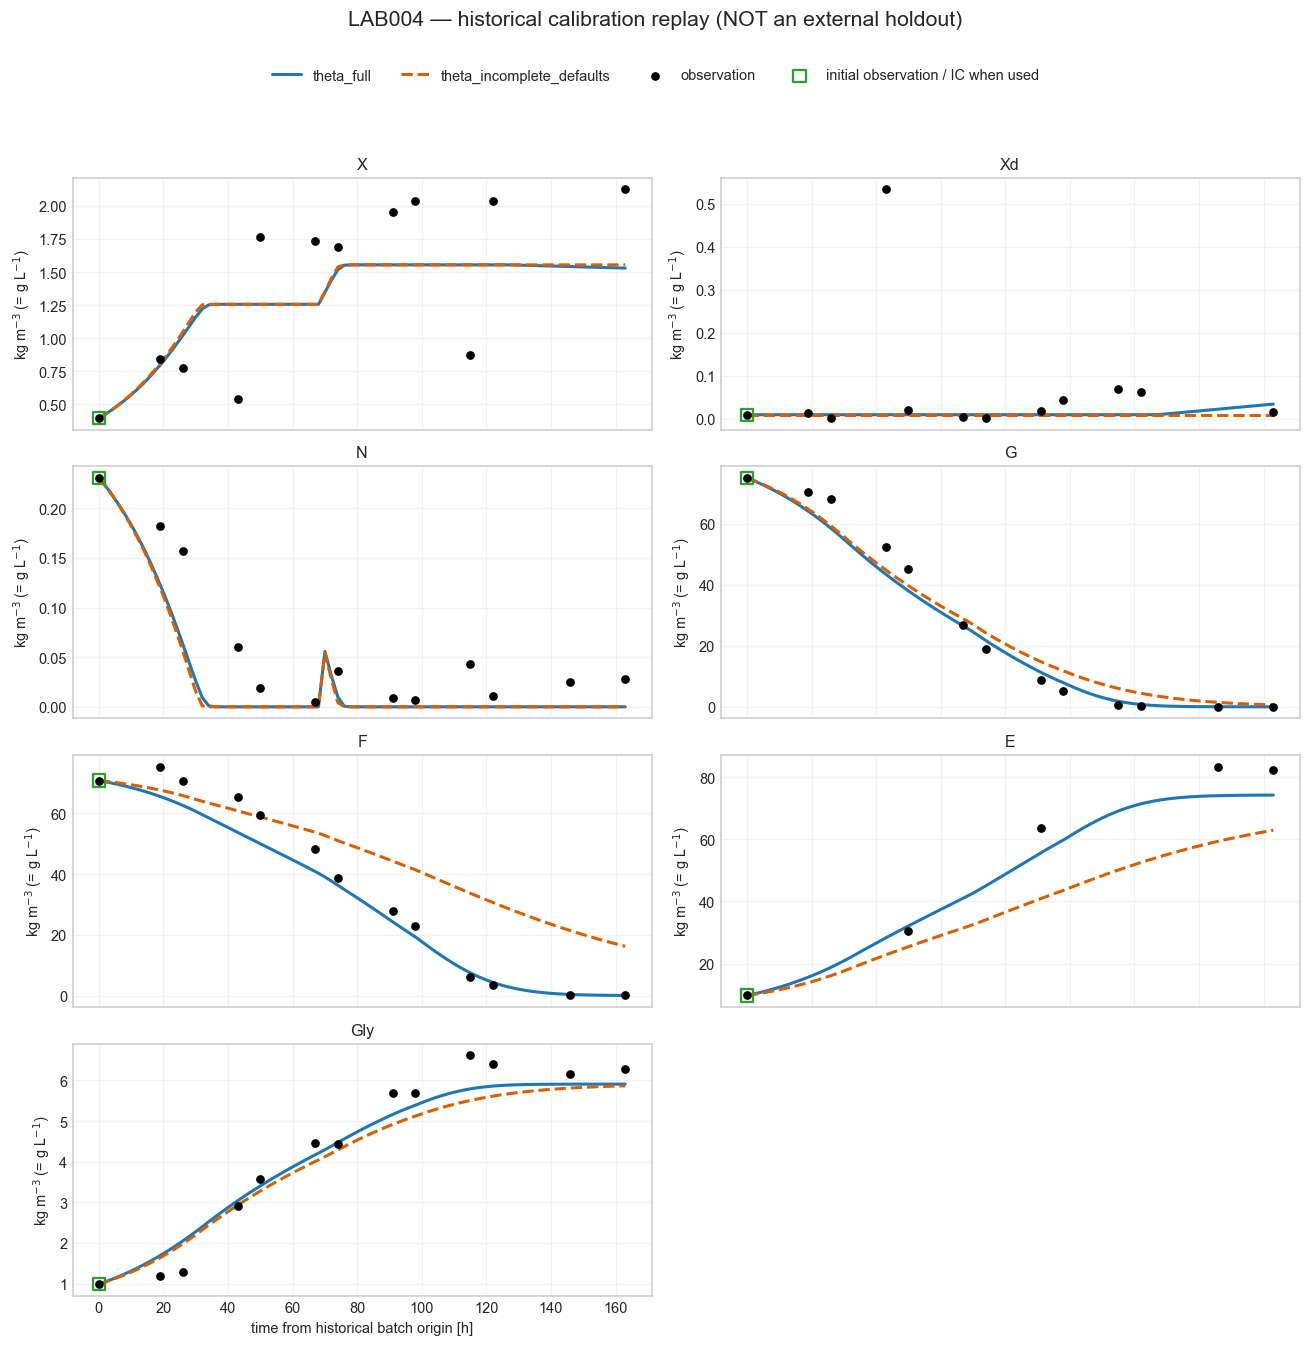

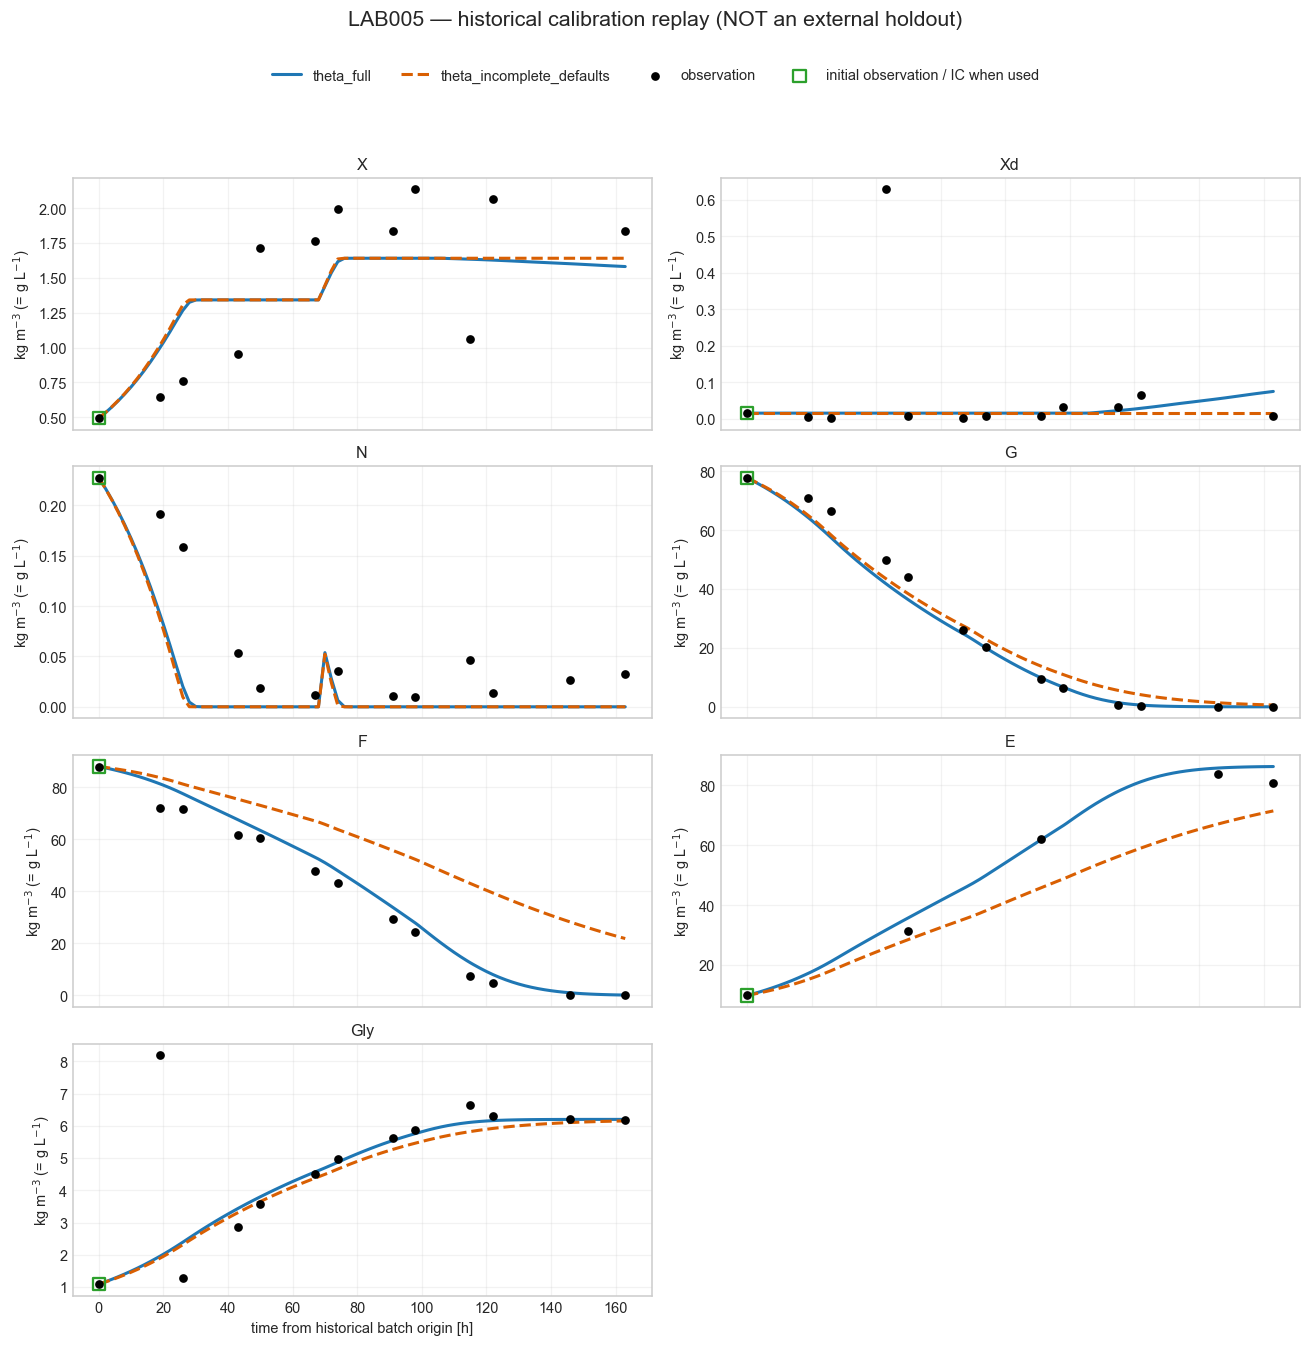

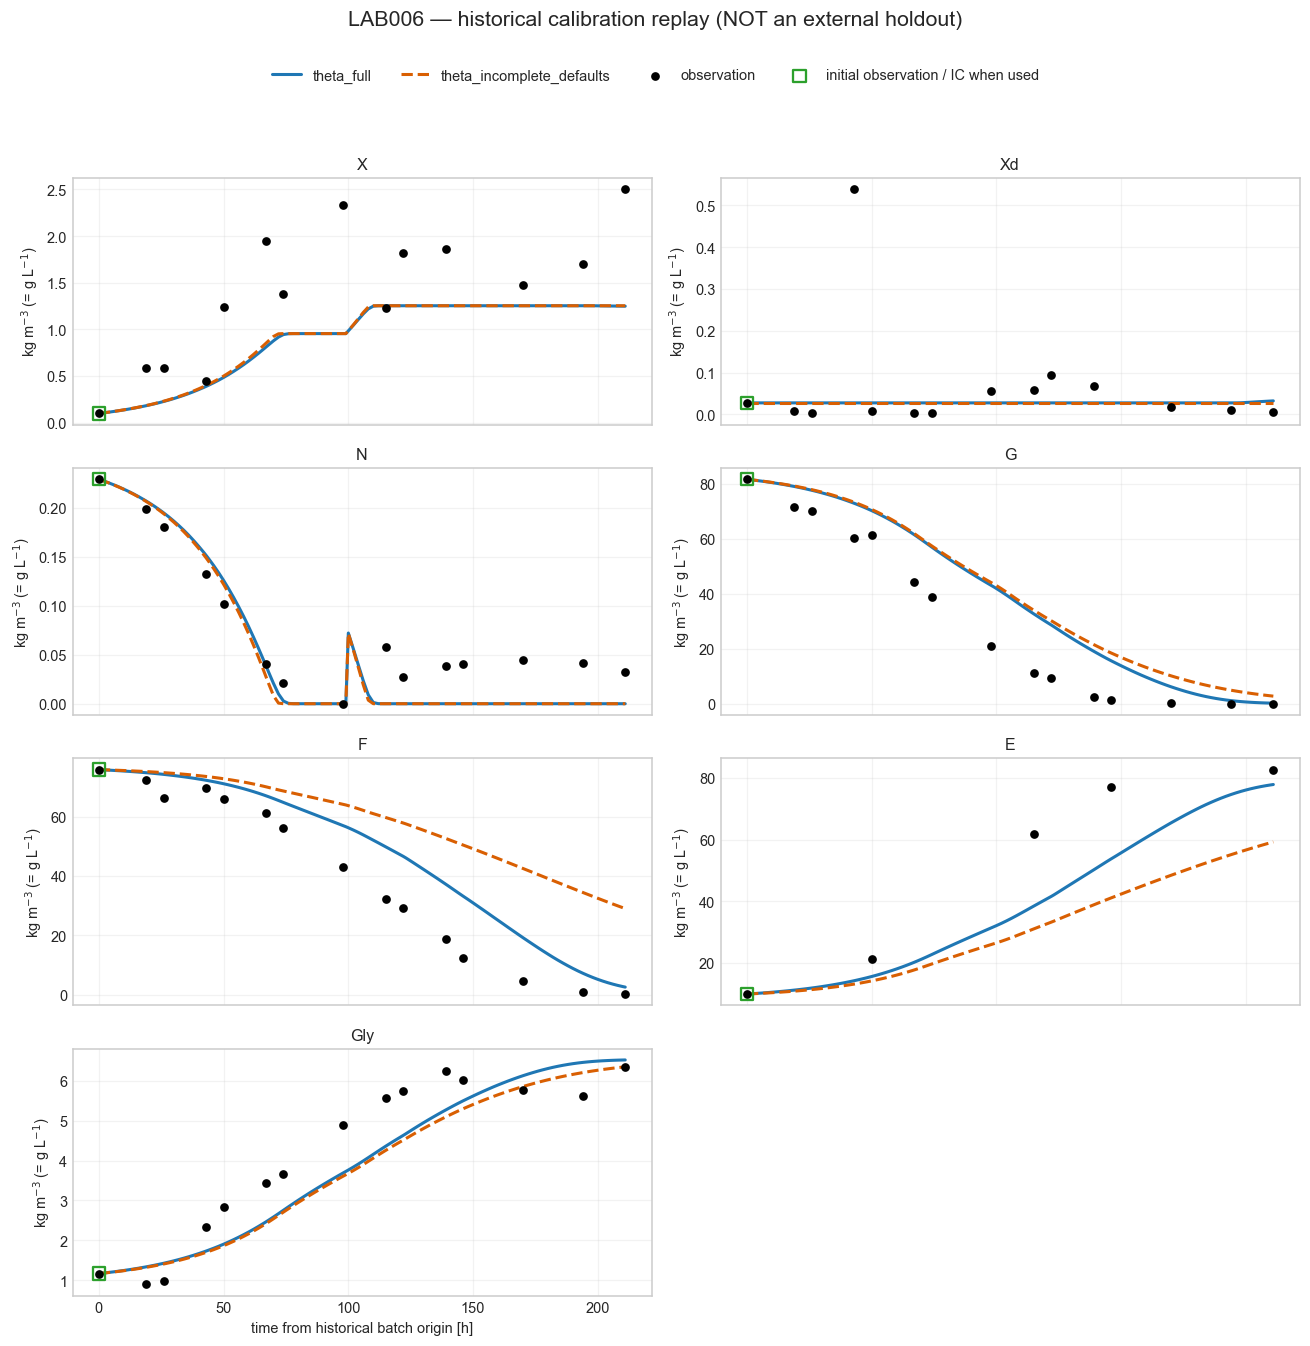

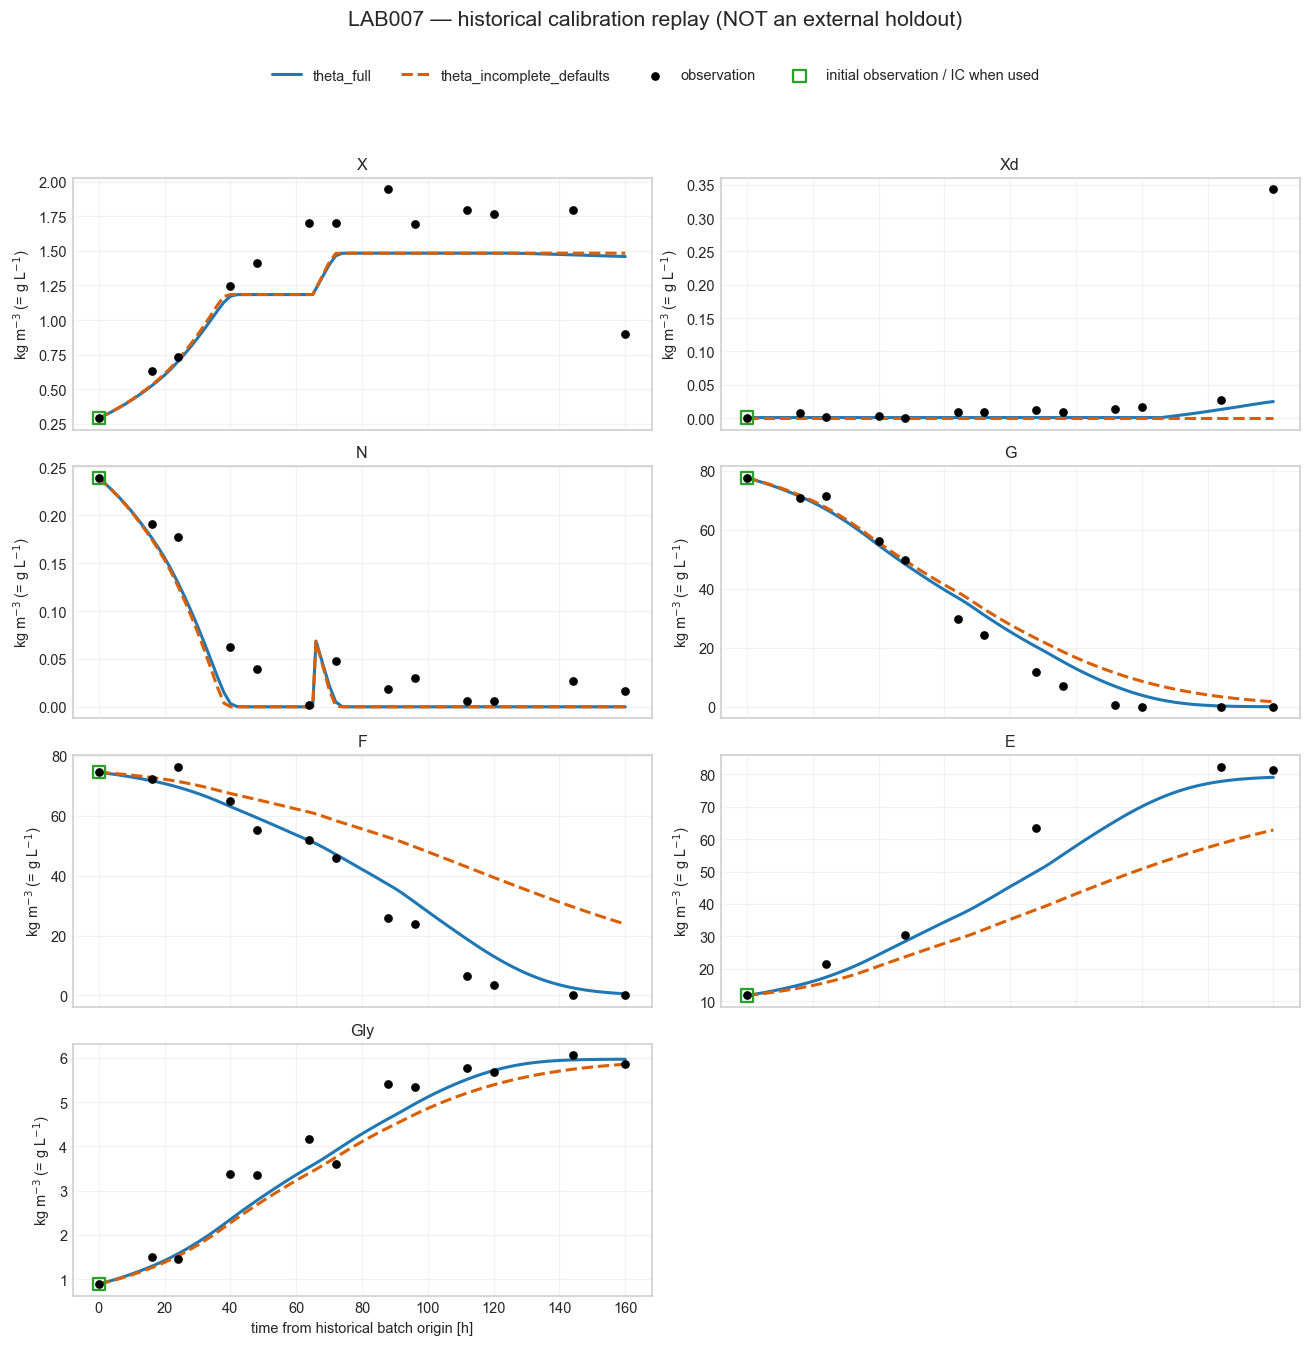

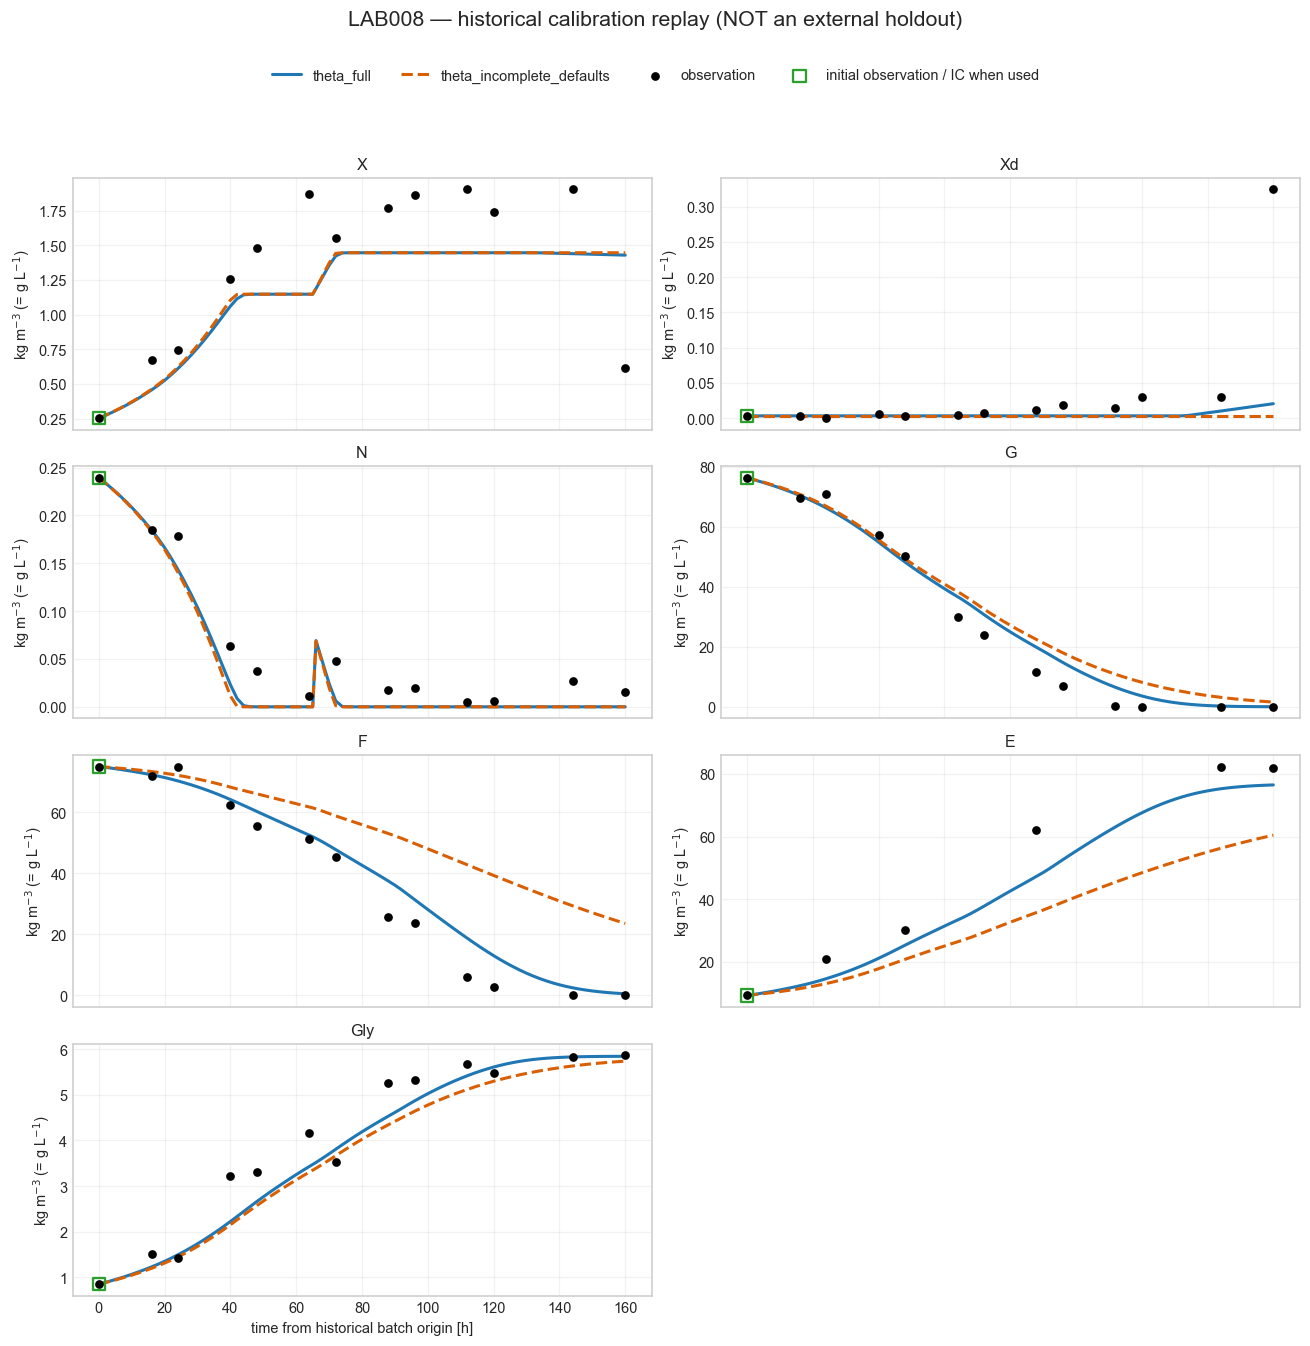

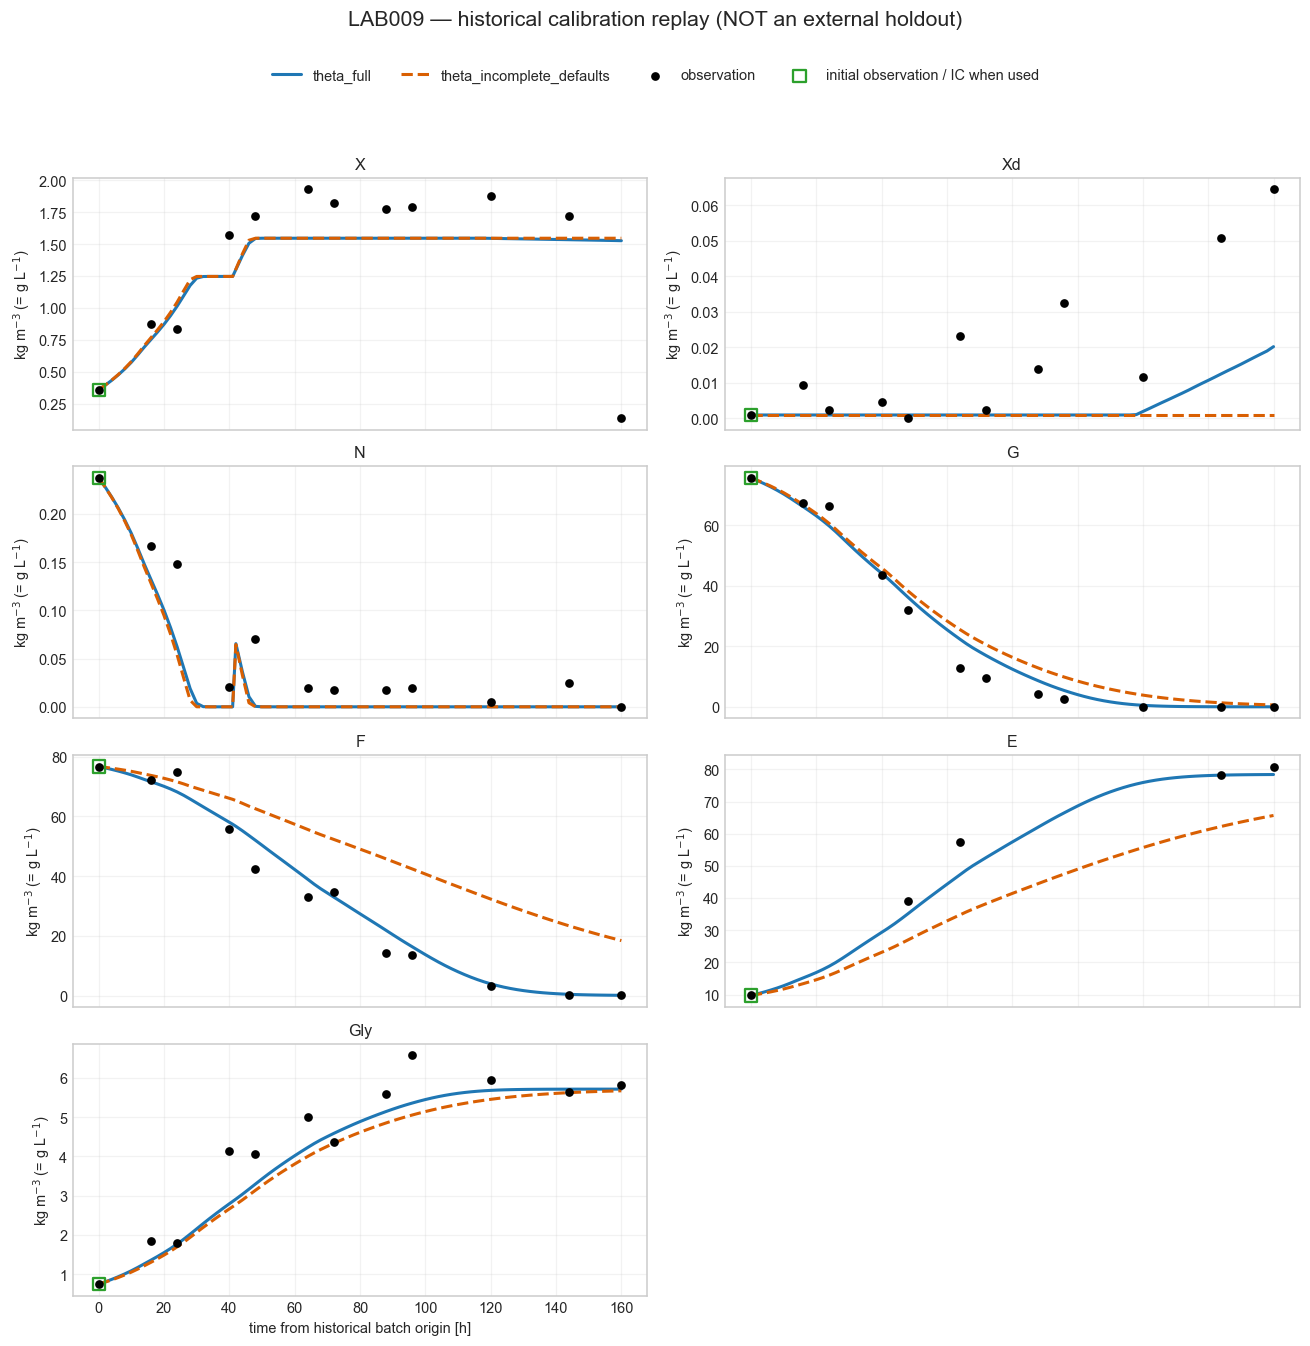

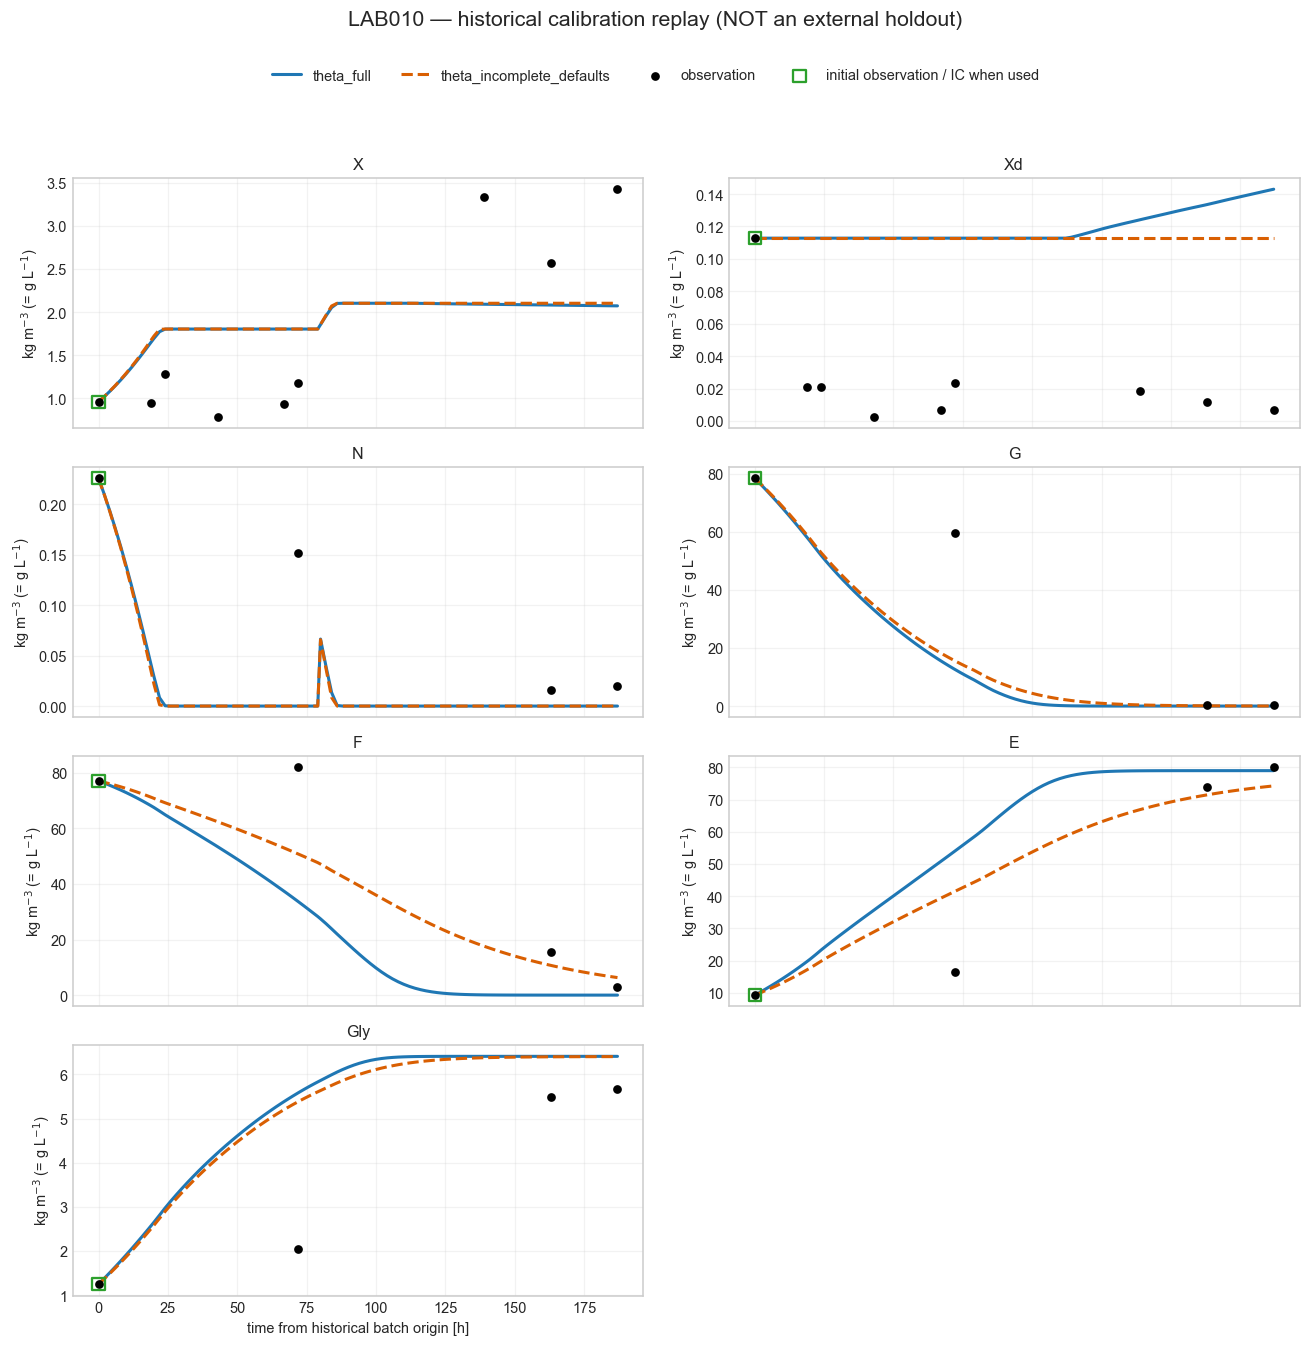

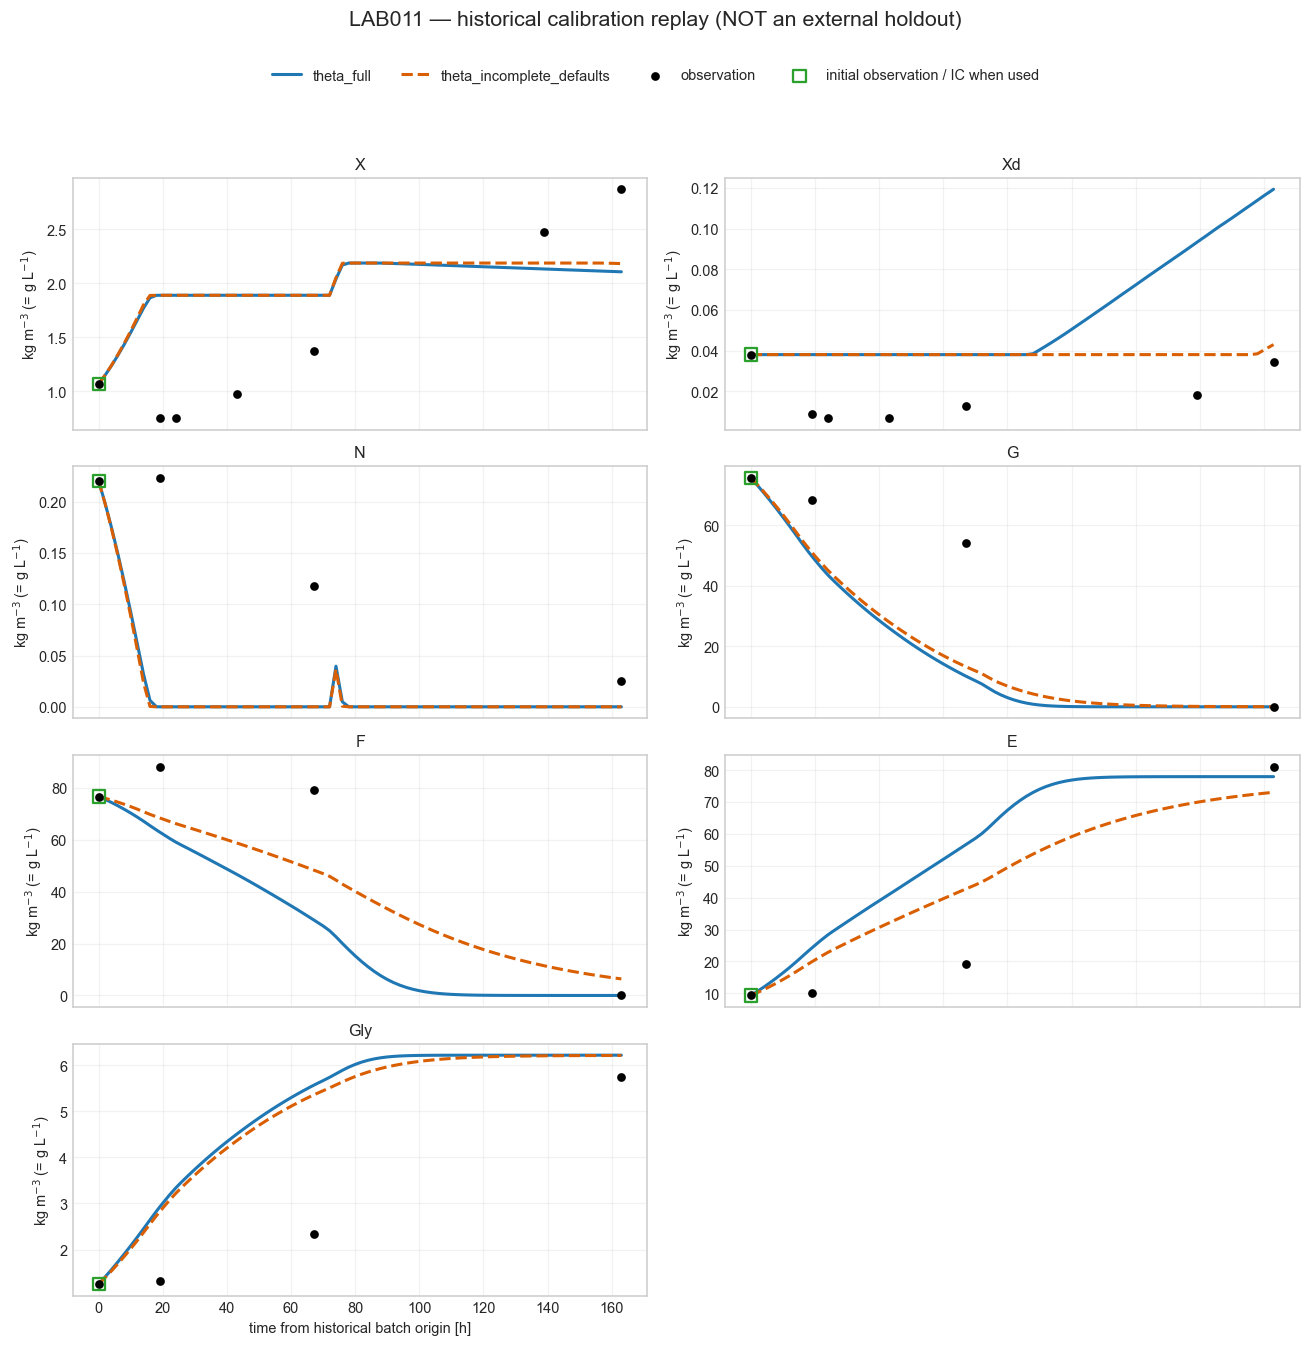

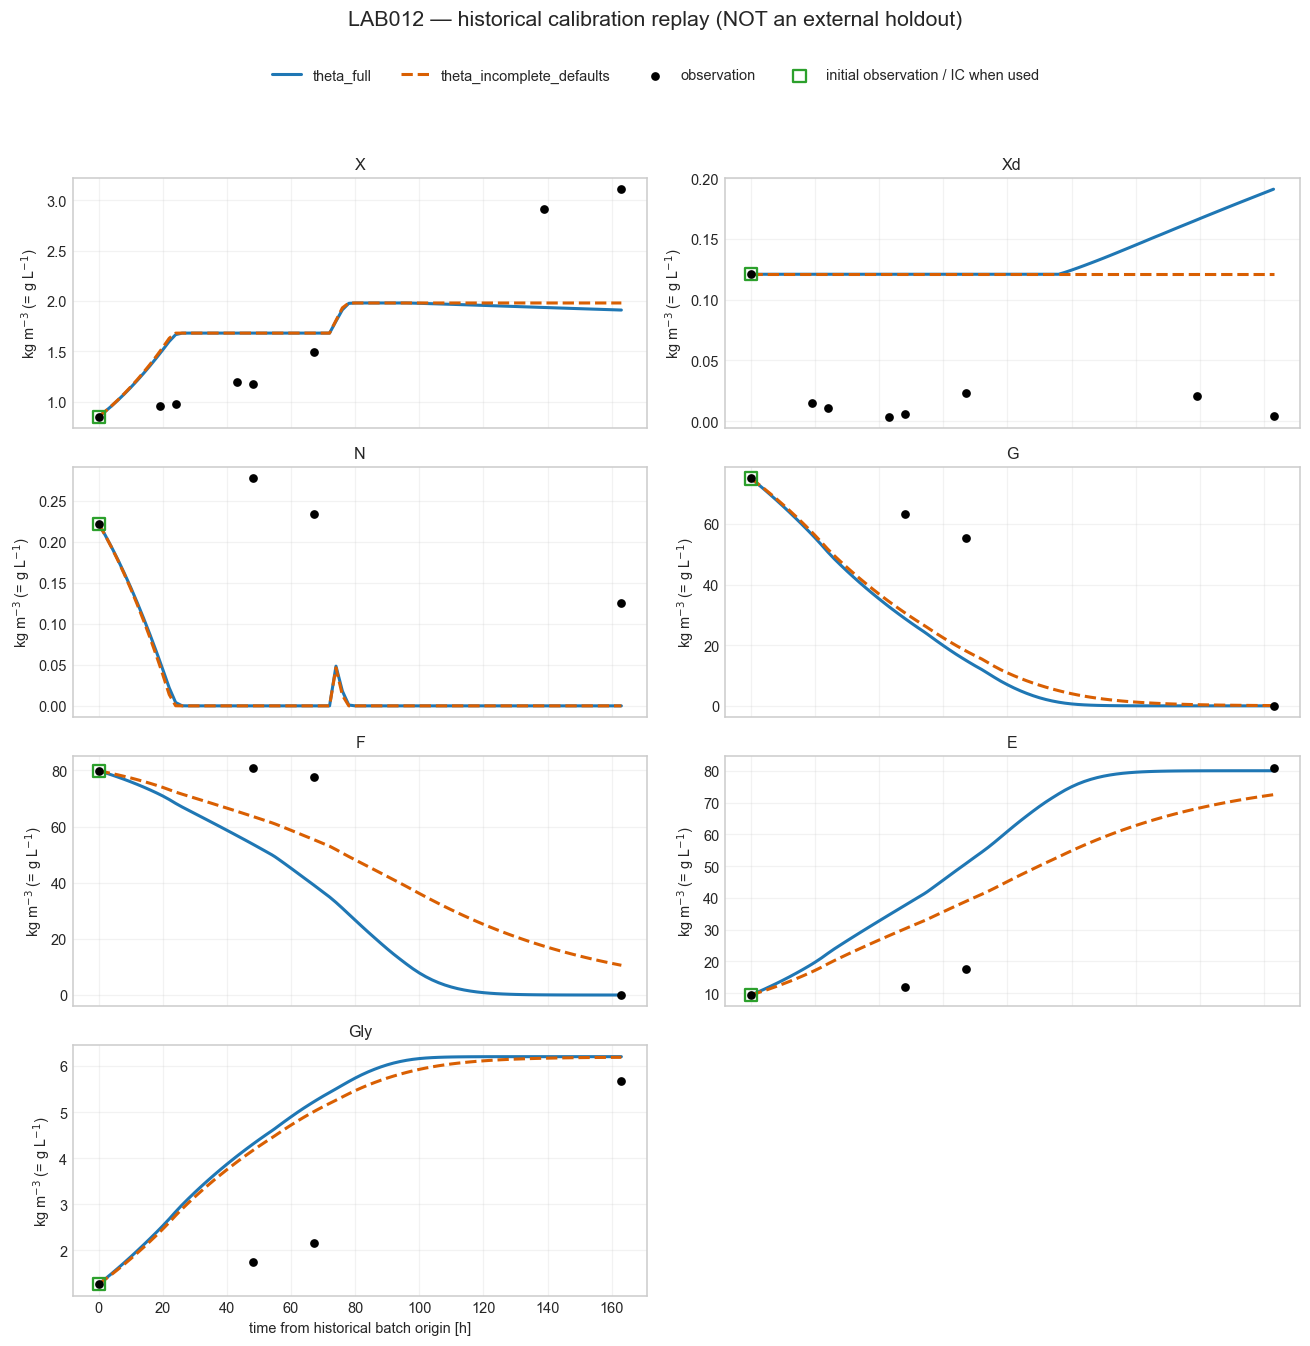

In [7]:
for batch in historical_batches:
    fig, axes = plt.subplots(4, 2, figsize=(12.5, 12.5), sharex=True)
    for ax, state in zip(axes.flat, kinetic.STATE_NAMES):
        for theta_label in theta_sets:
            sim = replay_trajectories[theta_label][batch.batch]
            ax.plot(sim.index, sim[state], color=COLORS[theta_label], ls=STYLES[theta_label],
                    lw=2.0, label=theta_label)
        obs = calibration_replay_points[
            calibration_replay_points["theta"].eq("theta_full")
            & calibration_replay_points["batch"].eq(batch.batch)
            & calibration_replay_points["state"].eq(state)
        ]
        ax.scatter(obs["time_h"], obs["observed"], color="black", s=22, zorder=4, label="observation")
        first = obs[obs["is_first_observation"]]
        ax.scatter(first["time_h"], first["observed"], marker="s", s=65, facecolors="none",
                   edgecolors="#2ca02c", linewidths=1.5, zorder=5, label="initial observation / IC when used")
        ax.set_title(state)
        ax.set_ylabel(STATE_UNITS[state])
        ax.grid(alpha=0.25)
    axes.flat[-1].axis("off")
    axes[3, 0].set_xlabel("time from historical batch origin [h]")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.suptitle(f"{batch.batch} — historical calibration replay (NOT an external holdout)", y=0.995, fontsize=14)
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.962), ncol=4, frameon=False)
    fig.tight_layout(rect=(0.02, 0.02, 0.98, 0.925))
    fig.savefig(FIGURE_DIR / f"calibration_replay_{batch.batch}.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

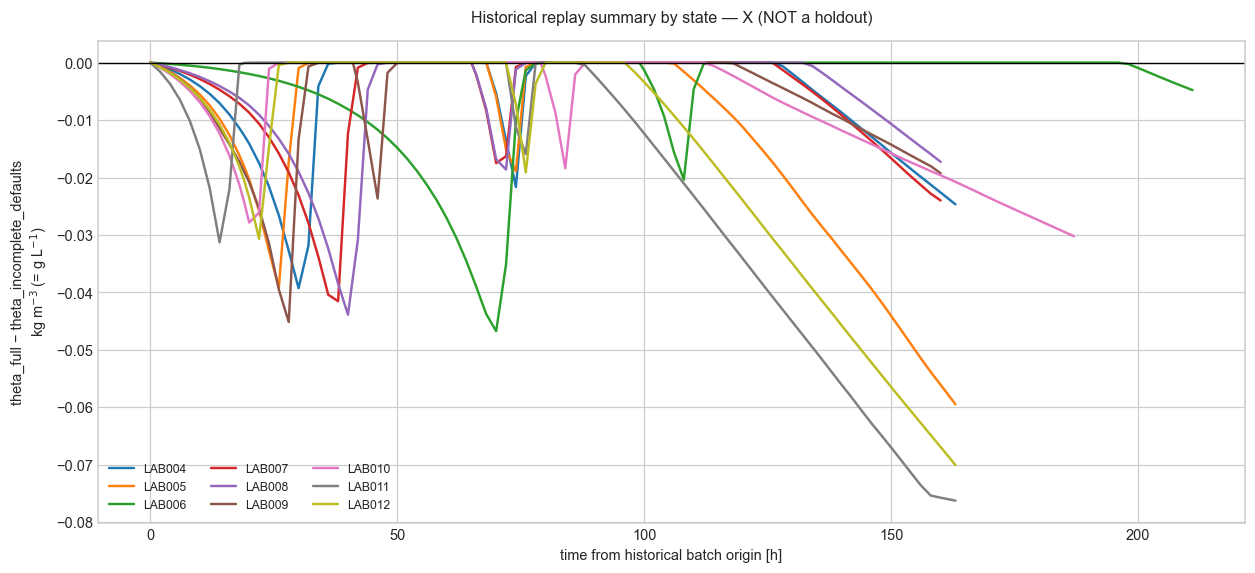

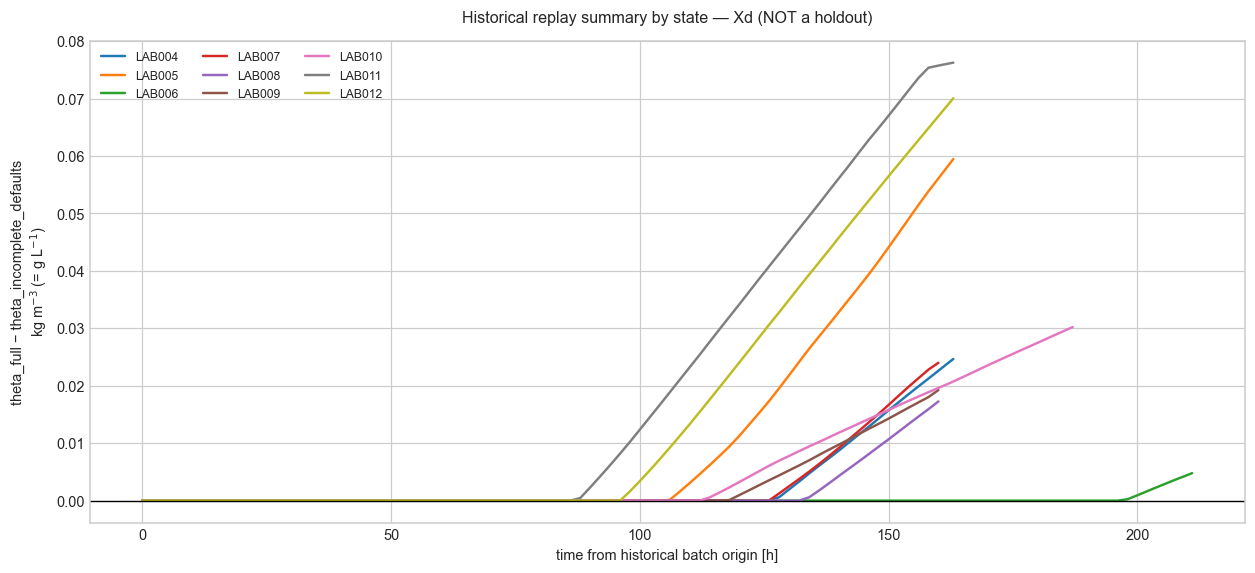

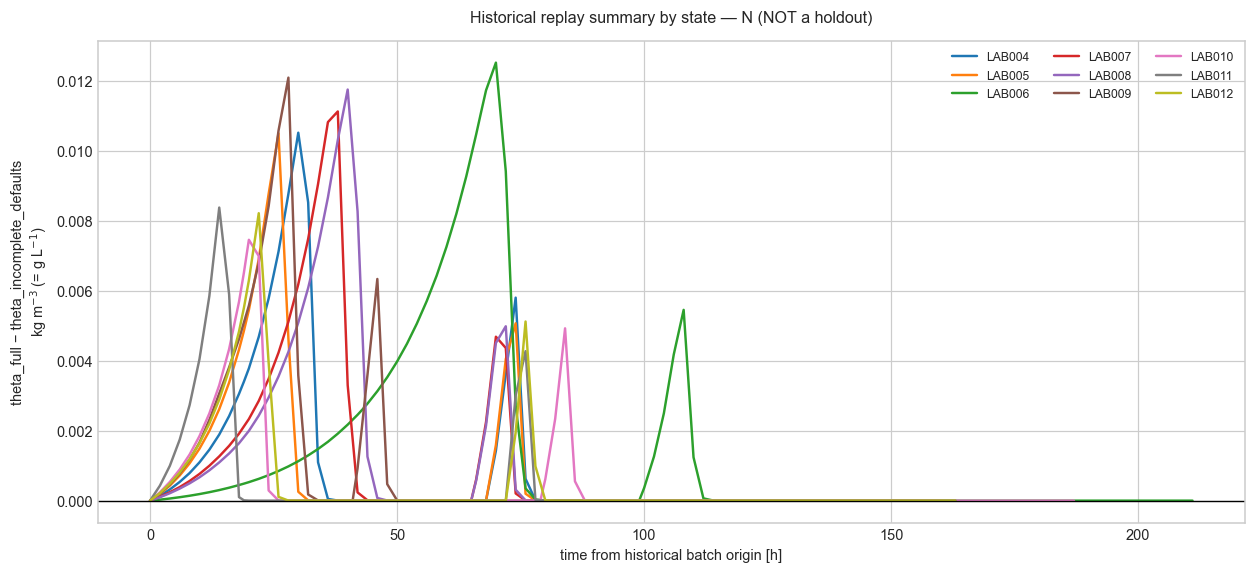

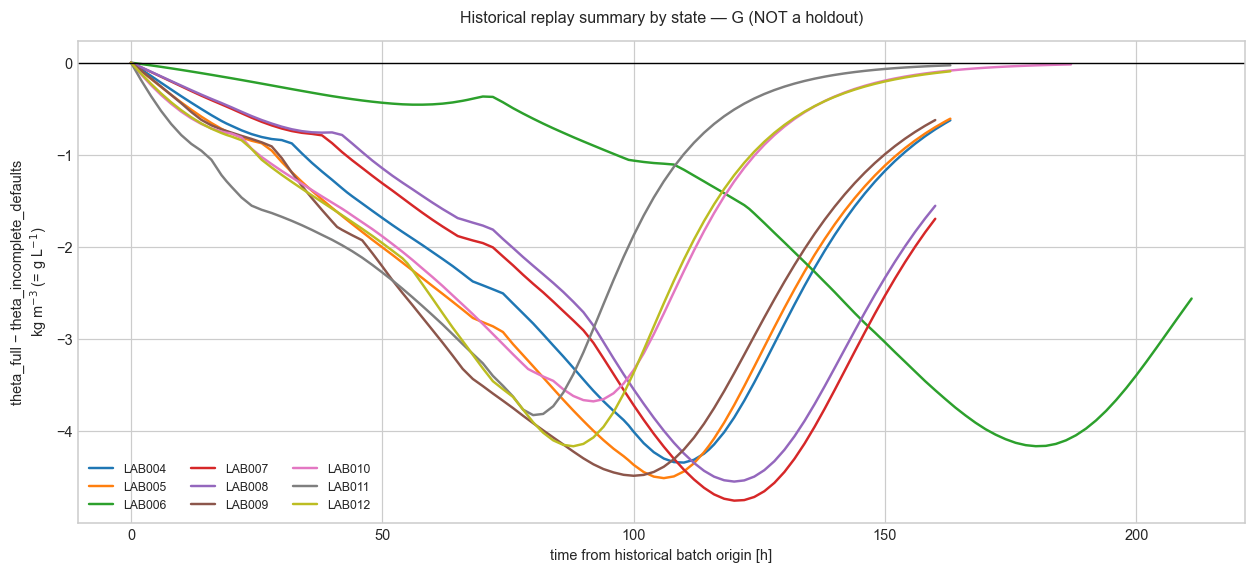

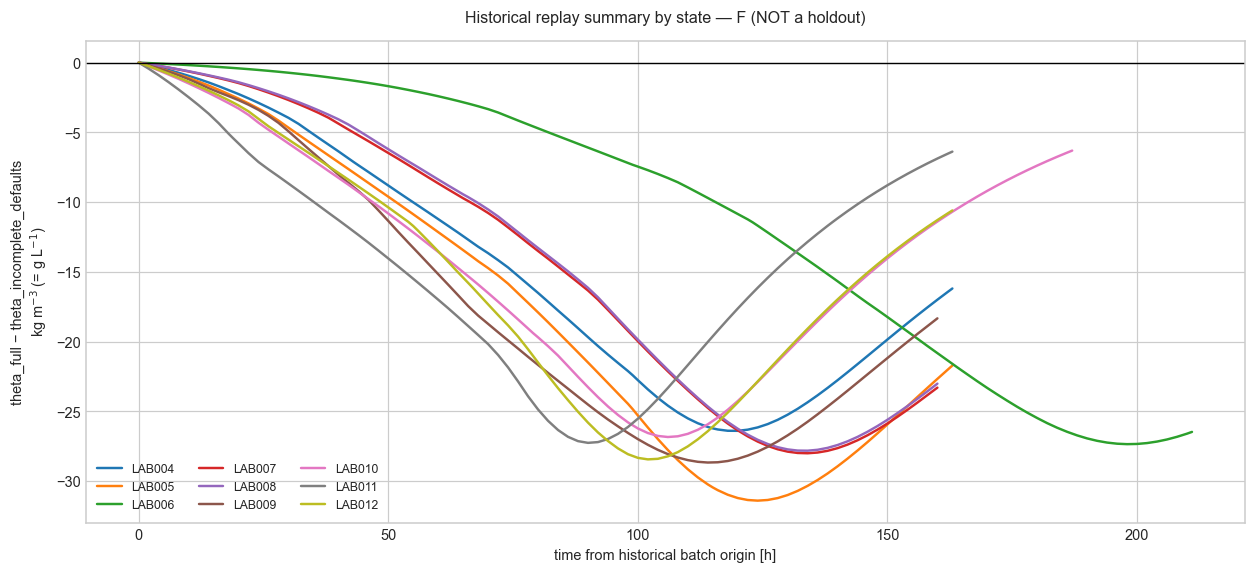

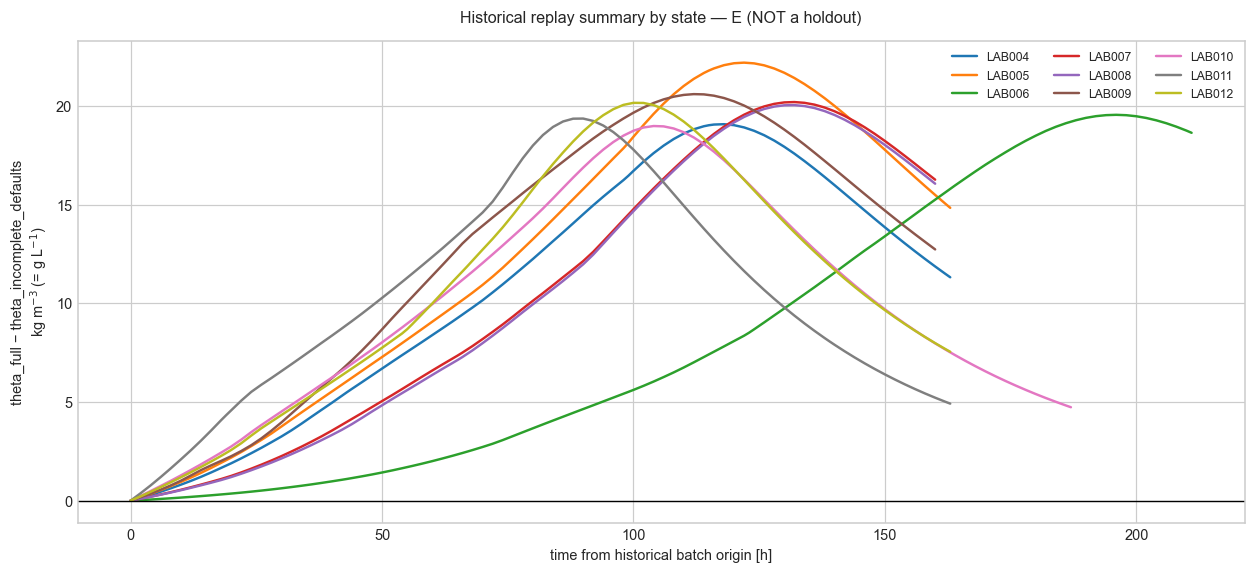

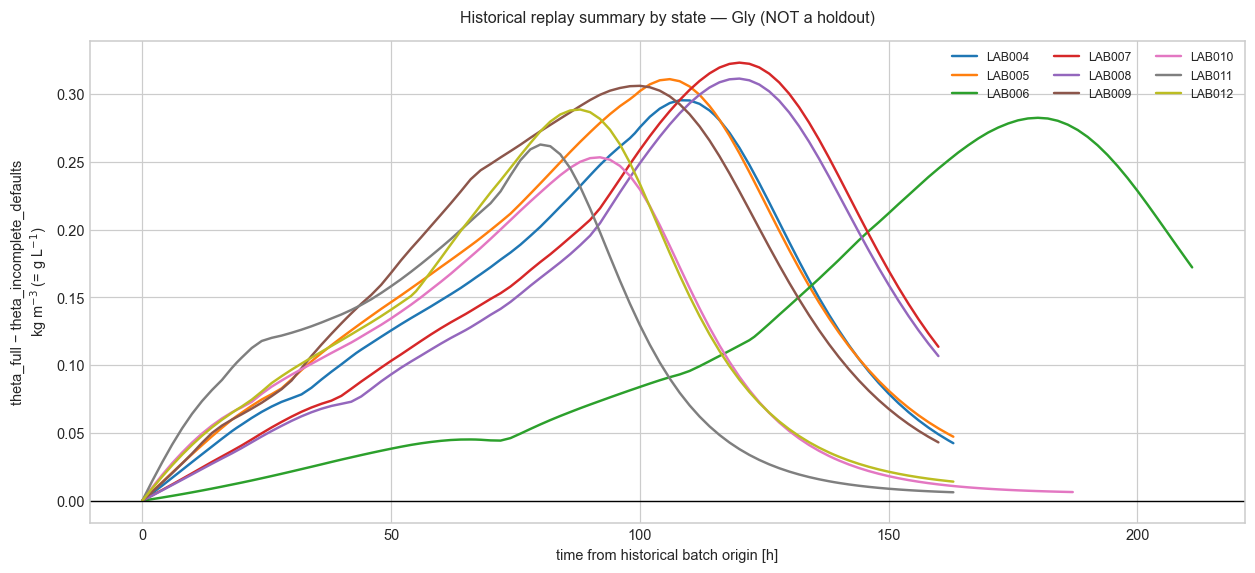

In [8]:
summary_delta_rows = []
for state in kinetic.STATE_NAMES:
    fig, ax = plt.subplots(figsize=(11.5, 5.3))
    for batch in historical_batches:
        full_sim = replay_trajectories["theta_full"][batch.batch]
        incomplete_sim = replay_trajectories["theta_incomplete_defaults"][batch.batch]
        delta = full_sim[state].to_numpy(float) - incomplete_sim[state].to_numpy(float)
        ax.plot(full_sim.index, delta, lw=1.6, label=batch.batch)
        summary_delta_rows.append({
            "batch": batch.batch, "state": state,
            "max_abs_theta_full_minus_incomplete": float(np.max(np.abs(delta))),
            "rms_theta_full_minus_incomplete": float(np.sqrt(np.mean(delta ** 2))),
        })
    ax.axhline(0.0, color="black", lw=0.9)
    ax.set_xlabel("time from historical batch origin [h]")
    ax.set_ylabel(f"theta_full − theta_incomplete_defaults\n{STATE_UNITS[state]}")
    ax.set_title(f"Historical replay summary by state — {state} (NOT a holdout)", pad=12)
    ax.legend(ncol=3, frameon=False, fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"calibration_replay_summary_state_{state}.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)
calibration_replay_trajectory_differences = pd.DataFrame(summary_delta_rows)

### Dynamic-feature definitions

- `X_plateau_h`: first time at which X reaches 95% of its trajectory maximum.
- N/G/F 50%, 20% and 10% times: first crossing relative to the simulated initial value.
- Fermentation termination: first time `G + F <= 4 kg m^-3`.
- If a crossing is absent within the complete available horizon, its status is
  `not reached` and the numeric time is left missing.

In [9]:
def first_crossing(time, values, threshold, direction="below"):
    values = np.asarray(values, float)
    hit = values <= threshold if direction == "below" else values >= threshold
    indices = np.flatnonzero(hit)
    return (float(time[indices[0]]), "reached") if len(indices) else (np.nan, "not reached")


def dynamic_features_for(batches, theta_label, theta, scope, step_h=0.25):
    rows = []
    for batch in batches:
        dense = np.arange(float(batch.time[0]), float(batch.time[-1]) + step_h * 0.5, step_h)
        output_time = np.unique(np.concatenate([dense, np.asarray(batch.time, float)]))
        output_time = output_time[output_time <= float(batch.time[-1]) + 1e-9]
        sim = kinetic.simulate(batch, theta, output_time)
        assert sim is not None
        t = sim.index.to_numpy(float)
        x = sim["X"].to_numpy(float)
        x_max = float(np.max(x))
        x_plateau_h, x_plateau_status = first_crossing(t, x, 0.95 * x_max, direction="above")
        row = {
            "scope": scope, "theta": theta_label, "batch": batch.batch,
            "time_reference": (
                "proxy h from numbered sample 1; NOT absolute inoculation age"
                if scope == "external holdout" else "historical batch time [h]"
            ),
            "horizon_h": float(t[-1]), "X_max": x_max,
            "X_max_time_h": float(t[int(np.argmax(x))]),
            "X_plateau_h": x_plateau_h, "X_plateau_status": x_plateau_status,
            "Xd_max": float(sim["Xd"].max()), "Xd_final": float(sim["Xd"].iloc[-1]),
            "E_final": float(sim["E"].iloc[-1]), "Gly_final": float(sim["Gly"].iloc[-1]),
            "G_final": float(sim["G"].iloc[-1]), "F_final": float(sim["F"].iloc[-1]),
            "N_final": float(sim["N"].iloc[-1]),
            "G_plus_F_final": float(sim["G"].iloc[-1] + sim["F"].iloc[-1]),
        }
        for state in ("N", "G", "F"):
            initial = float(sim[state].iloc[0])
            for pct, fraction in ((50, 0.50), (20, 0.20), (10, 0.10)):
                crossing, status = first_crossing(t, sim[state], fraction * initial, direction="below")
                row[f"{state}_t{pct}_h"] = crossing
                row[f"{state}_t{pct}_status"] = status
        termination_h, termination_status = first_crossing(
            t, sim["G"].to_numpy(float) + sim["F"].to_numpy(float), 4.0, direction="below"
        )
        row["termination_GplusF_le_4_h"] = termination_h
        row["termination_status"] = termination_status
        rows.append(row)
    return pd.DataFrame(rows)


dynamic_history = pd.concat([
    dynamic_features_for(historical_batches, label, theta, "historical calibration replay")
    for label, theta in theta_sets.items()
], ignore_index=True)
display(dynamic_history)

,scope,theta,batch,time_reference,horizon_h,X_max,X_max_time_h,X_plateau_h,X_plateau_status,Xd_max,...,G_t10_h,G_t10_status,F_t50_h,F_t50_status,F_t20_h,F_t20_status,F_t10_h,F_t10_status,termination_GplusF_le_4_h,termination_status
0,historical calibration replay,theta_full,LAB004,historical batch time [h],163.0,1.554481,90.75,73.00,reached,0.033964,...,99.00,reached,75.50,reached,104.75,reached,116.00,reached,124.75,reached
1,historical calibration replay,theta_full,LAB005,historical batch time [h],163.0,1.640859,89.50,72.50,reached,0.075368,...,95.50,reached,79.00,reached,109.00,reached,120.75,reached,131.75,reached
2,historical calibration replay,theta_full,LAB006,historical batch time [h],211.0,1.253456,129.25,107.00,reached,0.032388,...,164.25,reached,138.00,reached,177.25,reached,193.00,reached,205.50,reached
3,historical calibration replay,theta_full,LAB007,historical batch time [h],160.0,1.483104,88.75,70.50,reached,0.024899,...,110.25,reached,87.75,reached,117.50,reached,130.00,reached,140.25,reached
4,historical calibration replay,theta_full,LAB008,historical batch time [h],160.0,1.445676,89.50,70.50,reached,0.020569,...,109.50,reached,88.00,reached,117.25,reached,129.75,reached,139.75,reached
5,historical calibration replay,theta_full,LAB009,historical batch time [h],160.0,1.545679,62.00,45.25,reached,0.020152,...,90.50,reached,64.75,reached,97.50,reached,110.75,reached,121.25,reached
6,historical calibration replay,theta_full,LAB010,historical batch time [h],187.0,2.102583,97.25,83.00,reached,0.143014,...,81.25,reached,65.25,reached,93.25,reached,103.00,reached,110.25,reached
7,historical calibration replay,theta_full,LAB011,historical batch time [h],163.0,2.186892,86.50,74.50,reached,0.119277,...,72.25,reached,55.00,reached,80.00,reached,88.00,reached,94.50,reached
8,historical calibration replay,theta_full,LAB012,historical batch time [h],163.0,1.979489,89.75,75.50,reached,0.190953,...,79.25,reached,66.25,reached,90.50,reached,100.00,reached,107.50,reached
9,historical calibration replay,theta_incomplete_defaults,LAB004,historical batch time [h],163.0,1.554481,82.00,72.75,reached,0.009300,...,109.75,reached,111.25,reached,NaN,not reached,NaN,not reached,NaN,not reached


## External kinetic holdout — LAB013–LAB015

LAB013, LAB014 and LAB015 did not participate in the historical natural-theta calibration.
No parameter is adjusted here, and LAB016–LAB018 are not used.

The comparison uses the PI Y15 composition as N/G/F/Gly initial conditions, the first
Oculyze sample for X/Xd initial conditions, the measured temperature record, no inferred
nutrient pulse, and the complete observed horizon. The clock is a **proxy** beginning at
numbered reactor sample 1; it must not be interpreted as absolute hours since inoculation.
This limitation is shared exactly by both frozen theta vectors, so their relative comparison
remains valid.

E is not scored because no valid directly comparable temporal ethanol series exists.

In [10]:
EXTERNAL_LABS = ("LAB013", "LAB014", "LAB015")
LAB_TO_FERMENTER = {"LAB013": "F1", "LAB014": "F2", "LAB015": "F3"}
EXTERNAL_DIR = FM / "data" / "mem2026" / "LAB013-015"
OFFLINE_PATH = EXTERNAL_DIR / "LAB013-LAB015-offline-measurements.csv"
COMBINED_PATH = EXTERNAL_DIR / "LAB013-LAB015-offline-combined.csv"
Y15_PATH = EXTERNAL_DIR / "Y15_LAB013-015.csv"
TEMP_PATHS = {lab: EXTERNAL_DIR / f"Temp_{LAB_TO_FERMENTER[lab]}_{lab}.csv" for lab in EXTERNAL_LABS}
OCULYZE_PATHS = {lab: EXTERNAL_DIR / f"{lab}_OCULYZE" / "report.csv" for lab in EXTERNAL_LABS}
assert all(path.exists() for path in [OFFLINE_PATH, COMBINED_PATH, Y15_PATH, *TEMP_PATHS.values(), *OCULYZE_PATHS.values()])

offline = pd.read_csv(OFFLINE_PATH)
combined = pd.read_csv(COMBINED_PATH)
y15 = pd.read_csv(Y15_PATH)
offline = offline[offline["lab_id"].isin(EXTERNAL_LABS)].copy()
combined = combined[combined["lab_id"].isin(EXTERNAL_LABS)].copy()
y15 = y15[y15["lab_id"].isin(EXTERNAL_LABS)].copy()
for frame in (offline, combined):
    frame["sample_datetime"] = pd.to_datetime(
        frame["fecha_muestreo"].astype(str) + " " + frame["hora_muestreo"].astype(str), errors="raise"
    )
y15["y15_datetime"] = pd.to_datetime(y15["y15_datetime"], errors="raise")
y15["y15_datetime_end"] = pd.to_datetime(y15["y15_datetime_end"], errors="coerce")
proxy_t0 = (
    offline[offline["lab_id"].isin(EXTERNAL_LABS) & offline["sample_id"].str.endswith("-1")]
    .set_index("lab_id")["sample_datetime"].to_dict()
)
assert set(proxy_t0) == set(EXTERNAL_LABS)
for frame in (offline, combined):
    frame["time_proxy_h"] = [
        (stamp - proxy_t0[lab]).total_seconds() / 3600.0
        for lab, stamp in zip(frame["lab_id"], frame["sample_datetime"])
    ]
for column in ["YAN_mg_L", "glucose_g_L", "fructose_g_L", "glycerol_g_L"]:
    y15[column] = pd.to_numeric(y15[column], errors="coerce")
    combined[column] = pd.to_numeric(combined[column], errors="coerce")
pi = y15[y15["lab_id"].isin(EXTERNAL_LABS) & y15["sample_type"].eq("pre_inoculum")].copy()
assert set(pi["lab_id"]) == set(EXTERNAL_LABS)

def align_oculyze(lab, path, schedule):
    report = pd.read_csv(path).copy()
    available = schedule[schedule["lab_id"].eq(lab)].copy()
    available_by_id = available.set_index("sample_id")["sample_datetime"].to_dict()
    used, aligned_ids, notes = set(), [], []
    for item in report.itertuples(index=False):
        raw_id = str(item.Name).strip()
        if raw_id in available_by_id and raw_id not in used:
            chosen, note = raw_id, "matched unique sample ID to offline ledger"
        else:
            parsed = pd.to_datetime(str(item.Description), dayfirst=True, errors="coerce")
            candidates = available[~available["sample_id"].isin(used)].copy()
            if pd.isna(parsed) or candidates.empty:
                raise ValueError(f"{lab}: cannot align Oculyze row {raw_id}")
            distance = (candidates["sample_datetime"] - parsed).abs()
            chosen = str(candidates.loc[distance.idxmin(), "sample_id"])
            note = f"repaired duplicate label {raw_id} by nearest unused ledger timestamp"
        used.add(chosen); aligned_ids.append(chosen); notes.append(note)
    report["batch"] = lab
    report["sample_id_raw"] = report["Name"].astype(str)
    report["sample_id"] = aligned_ids
    report["timestamp_source"] = notes
    report = report.merge(available[["sample_id", "sample_datetime"]], on="sample_id", how="left", validate="one_to_one")
    report["Concentration"] = pd.to_numeric(report["Concentration"], errors="raise")
    report["Viability"] = pd.to_numeric(report["Viability"], errors="raise")
    report["X_total_kg_m3"] = report["Concentration"] * 0.03
    report["X_obs_kg_m3"] = report["X_total_kg_m3"] * report["Viability"] / 100.0
    report["Xd_obs_kg_m3"] = report["X_total_kg_m3"] - report["X_obs_kg_m3"]
    report["time_proxy_h"] = (report["sample_datetime"] - proxy_t0[lab]).dt.total_seconds() / 3600.0
    return report

oculyze = pd.concat([align_oculyze(lab, OCULYZE_PATHS[lab], offline) for lab in EXTERNAL_LABS], ignore_index=True)

external_batches = []
external_initial_rows, external_source_rows = [], []
for lab in EXTERNAL_LABS:
    chemistry = combined[combined["lab_id"].eq(lab)].dropna(subset=["glucose_g_L", "fructose_g_L"]).sort_values("time_proxy_h")
    biomass = oculyze[oculyze["batch"].eq(lab)].sort_values("time_proxy_h")
    horizon_h = float(max(chemistry["time_proxy_h"].max(), biomass["time_proxy_h"].max()))
    regular_grid = np.arange(0.0, horizon_h + 0.125, 0.25)
    model_time = np.unique(np.concatenate([
        regular_grid[regular_grid <= horizon_h + 1e-9], chemistry["time_proxy_h"].to_numpy(float),
        biomass["time_proxy_h"].to_numpy(float), np.array([horizon_h])
    ]))
    temp = pd.read_csv(TEMP_PATHS[lab])
    temp["timestamp"] = pd.to_datetime(temp["timestamp"], errors="raise")
    temp["T"] = pd.to_numeric(temp["T"], errors="raise")
    active = pd.to_numeric(temp["nutricion_activa"], errors="coerce").fillna(0.0)
    assert active.eq(0.0).all(), f"{lab}: undeclared nutrition edge"
    temp = temp.set_index("timestamp")["T"].resample("30min").median().dropna().reset_index()
    temp["time_proxy_h"] = (temp["timestamp"] - proxy_t0[lab]).dt.total_seconds() / 3600.0
    first_offline_temp = float(pd.to_numeric(
        offline.loc[offline["sample_id"].eq(f"{lab}-1"), "temperature_C"], errors="raise"
    ).iloc[0])
    temp_grid = pd.concat([
        pd.DataFrame({"timestamp": [proxy_t0[lab]], "T": [first_offline_temp], "time_proxy_h": [0.0]}),
        temp[["timestamp", "T", "time_proxy_h"]]
    ], ignore_index=True).sort_values("time_proxy_h").drop_duplicates("time_proxy_h")
    temperature = np.interp(model_time, temp_grid["time_proxy_h"], temp_grid["T"])

    observations = {state: np.full(len(model_time), np.nan) for state in kinetic.STATE_NAMES}
    for row in chemistry.itertuples(index=False):
        idx = int(np.argmin(np.abs(model_time - float(row.time_proxy_h))))
        observations["G"][idx] = float(row.glucose_g_L)
        observations["F"][idx] = float(row.fructose_g_L)
        observations["N"][idx] = float(row.YAN_mg_L) * 1e-3
        observations["Gly"][idx] = float(row.glycerol_g_L)
    for row in biomass.itertuples(index=False):
        idx = int(np.argmin(np.abs(model_time - float(row.time_proxy_h))))
        observations["X"][idx] = float(row.X_obs_kg_m3)
        observations["Xd"][idx] = float(row.Xd_obs_kg_m3)

    pi_row = pi[pi["lab_id"].eq(lab)].iloc[0]
    first_biomass = biomass.iloc[0]
    initials = {
        "X": float(first_biomass.X_obs_kg_m3), "Xd": float(first_biomass.Xd_obs_kg_m3),
        "N": float(pi_row.YAN_mg_L) * 1e-3, "G": float(pi_row.glucose_g_L),
        "F": float(pi_row.fructose_g_L), "E": 0.0, "Gly": float(pi_row.glycerol_g_L),
    }
    external_batches.append(kinetic.BatchData(
        medium="natural", batch=lab, time=model_time, temperature_c=temperature,
        pulses={channel: tuple() for channel in kinetic.INPUT_CHANNELS},
        observations=observations, initials=initials,
    ))
    external_initial_rows.append({"batch": lab, **initials})
    external_source_rows.append({
        "batch": lab, "role": "external kinetic holdout", "used_for_fitting": False,
        "proxy_origin": proxy_t0[lab], "absolute_hours_since_inoculation_valid": False,
        "horizon_proxy_h": horizon_h, "temperature_file": TEMP_PATHS[lab].relative_to(ROOT).as_posix(),
        "oculyze_file": OCULYZE_PATHS[lab].relative_to(ROOT).as_posix(),
        "chemistry_file": COMBINED_PATH.relative_to(ROOT).as_posix(),
        "PI_file": Y15_PATH.relative_to(ROOT).as_posix(), "nutrient_pulses": "none",
    })

external_initial_conditions = pd.DataFrame(external_initial_rows)
external_source_audit = pd.DataFrame(external_source_rows)
assert tuple(batch.batch for batch in external_batches) == EXTERNAL_LABS
display(external_source_audit)
display(external_initial_conditions)

,batch,role,used_for_fitting,proxy_origin,absolute_hours_since_inoculation_valid,horizon_proxy_h,temperature_file,oculyze_file,chemistry_file,PI_file,nutrient_pulses
0,LAB013,external kinetic holdout,False,2026-08-18 10:00:00,False,143.5,fermentation_model/data/mem2026/LAB013-015/Tem...,fermentation_model/data/mem2026/LAB013-015/LAB...,fermentation_model/data/mem2026/LAB013-015/LAB...,fermentation_model/data/mem2026/LAB013-015/Y15...,none
1,LAB014,external kinetic holdout,False,2026-08-18 10:00:00,False,143.5,fermentation_model/data/mem2026/LAB013-015/Tem...,fermentation_model/data/mem2026/LAB013-015/LAB...,fermentation_model/data/mem2026/LAB013-015/LAB...,fermentation_model/data/mem2026/LAB013-015/Y15...,none
2,LAB015,external kinetic holdout,False,2026-08-18 10:00:00,False,143.5,fermentation_model/data/mem2026/LAB013-015/Tem...,fermentation_model/data/mem2026/LAB013-015/LAB...,fermentation_model/data/mem2026/LAB013-015/LAB...,fermentation_model/data/mem2026/LAB013-015/Y15...,none


,batch,X,Xd,N,G,F,E,Gly
0,LAB013,0.411354,0.044946,0.249,75.62,79.03,0.0,1.15
1,LAB014,0.436705,0.026495,0.247,76.54,80.38,0.0,1.12
2,LAB015,0.479344,0.041456,0.246,75.32,79.45,0.0,1.12


In [11]:
def external_points_for_theta(theta_label, theta):
    rows, trajectories = [], {}
    for batch in external_batches:
        sim = kinetic.simulate(batch, theta, batch.time)
        assert sim is not None
        trajectories[batch.batch] = sim
        chemistry = combined[combined["lab_id"].eq(batch.batch)].sort_values("time_proxy_h")
        biomass = oculyze[oculyze["batch"].eq(batch.batch)].sort_values("time_proxy_h")
        for state, column, factor in (
            ("G", "glucose_g_L", 1.0), ("F", "fructose_g_L", 1.0),
            ("N", "YAN_mg_L", 1e-3), ("Gly", "glycerol_g_L", 1.0),
        ):
            available = chemistry.dropna(subset=[column]).sort_values("time_proxy_h")
            for order, row in enumerate(available.itertuples(index=False)):
                observed = float(getattr(row, column)) * factor
                predicted = float(np.interp(row.time_proxy_h, sim.index, sim[state]))
                sigma = float(kinetic.sigma_for_state(state, np.array([observed]))[0])
                rows.append({
                    "scope": "external holdout", "theta": theta_label, "batch": batch.batch,
                    "state": state, "unit": STATE_UNITS[state], "time_h": float(row.time_proxy_h),
                    "observed": observed, "predicted": predicted, "sigma": sigma,
                    "error_pred_minus_obs": predicted - observed,
                    "initial_condition_anchor": False, "is_first_observation": order == 0,
                    "is_last_observation": order == len(available) - 1, "used_in_score": True,
                    "sample_id": row.sample_id,
                })
        for state, column in (("X", "X_obs_kg_m3"), ("Xd", "Xd_obs_kg_m3")):
            for order, row in enumerate(biomass.itertuples(index=False)):
                observed = float(getattr(row, column))
                predicted = float(np.interp(row.time_proxy_h, sim.index, sim[state]))
                anchor = bool(np.isclose(row.time_proxy_h, 0.0))
                sigma = float(kinetic.sigma_for_state(state, np.array([observed]))[0])
                rows.append({
                    "scope": "external holdout", "theta": theta_label, "batch": batch.batch,
                    "state": state, "unit": STATE_UNITS[state], "time_h": float(row.time_proxy_h),
                    "observed": observed, "predicted": predicted, "sigma": sigma,
                    "error_pred_minus_obs": predicted - observed,
                    "initial_condition_anchor": anchor, "is_first_observation": order == 0,
                    "is_last_observation": order == len(biomass) - 1, "used_in_score": not anchor,
                    "sample_id": row.sample_id,
                })
    return pd.DataFrame(rows), trajectories

holdout_point_frames, holdout_trajectories = [], {}
for theta_label, theta in theta_sets.items():
    points, trajectories = external_points_for_theta(theta_label, theta)
    holdout_point_frames.append(points)
    holdout_trajectories[theta_label] = trajectories
external_holdout_points = pd.concat(holdout_point_frames, ignore_index=True)

external_holdout_metrics_by_state_batch = metrics_by_group(
    external_holdout_points, ["theta", "batch", "state"], endpoints=True
)
external_holdout_metrics_by_state = metrics_by_group(
    external_holdout_points, ["theta", "state"], endpoints=False
)
external_holdout_metrics_global = normalized_aggregate(
    external_holdout_points, ["theta"], external_holdout_metrics_by_state_batch
)
external_holdout_metrics_global["metric_label"] = "external holdout metrics; LAB013–LAB015"
display(external_holdout_metrics_global)
display(external_holdout_metrics_by_state)
display(external_holdout_metrics_by_state_batch)

,theta,n_observations,wsse,weighted_rmse_sigma_units,note,mean_state_nrmse_observed_range,metric_label
0,theta_full,132,4577.150723,5.888581,Raw RMSE is not pooled across states with diff...,1.064795,external holdout metrics; LAB013–LAB015
1,theta_incomplete_defaults,132,4266.353886,5.685144,Raw RMSE is not pooled across states with diff...,0.907029,external holdout metrics; LAB013–LAB015


,theta,state,n_observations,rmse,nrmse_observed_range,bias_pred_minus_obs,r2,wsse,weighted_rmse_sigma_units
0,theta_full,F,21,10.770231,1.144552,-7.294659,-18.315719,389.752833,4.308092
1,theta_full,G,21,19.152251,1.143418,-14.667337,-11.864237,1232.477249,7.660900
2,theta_full,Gly,21,1.199016,0.915279,0.939618,-8.348340,246.452402,3.425760
3,theta_full,N,21,0.113340,1.089803,-0.090829,-11.104220,1238.759504,7.680400
4,theta_full,X,24,0.497768,0.256551,0.327132,-0.196767,1452.772479,7.780243
5,theta_full,Xd,24,0.050403,0.278717,-0.017044,-0.126128,16.936256,0.840046
6,theta_incomplete_defaults,F,21,5.791056,0.615415,-3.545898,-4.584399,112.682067,2.316422
7,theta_incomplete_defaults,G,21,18.551792,1.107570,-14.127943,-11.070246,1156.407811,7.420717
8,theta_incomplete_defaults,Gly,21,1.147803,0.876185,0.894562,-7.566811,225.848787,3.279437
9,theta_incomplete_defaults,N,21,0.114860,1.104423,-0.092267,-11.431154,1262.316993,7.753085


,theta,batch,state,n_observations,rmse,nrmse_observed_range,bias_pred_minus_obs,r2,wsse,weighted_rmse_sigma_units,initial_time_h,observed_initial,predicted_initial,final_time_h,observed_final,predicted_final
0,theta_full,LAB013,F,7,9.982455,1.528707,-6.535917,-20.057390,111.607345,3.992982,2.5,75.470000,78.347369,53.0,72.960000,5.423129e+01
1,theta_full,LAB013,G,7,18.177608,1.364685,-13.320388,-11.708350,370.076498,7.271043,2.5,71.130000,74.017574,53.0,61.990000,3.118510e+01
2,theta_full,LAB013,Gly,7,1.163823,1.119061,0.905209,-9.566074,77.399111,3.325209,2.5,1.130000,1.255115,53.0,2.160000,4.062625e+00
3,theta_full,LAB013,N,7,0.109608,1.336678,-0.084987,-12.617335,392.760523,7.490570,2.5,0.237000,0.239505,53.0,0.164000,1.082717e-12
4,theta_full,LAB013,X,8,0.552560,0.308642,0.266150,0.021659,526.717528,8.114166,0.0,0.411354,0.411354,143.5,2.110664,1.341283e+00
5,theta_full,LAB013,Xd,8,0.059644,0.354620,-0.022866,-0.172301,7.905392,0.994069,0.0,0.044946,0.044946,143.5,0.017236,4.494555e-02
6,theta_full,LAB014,F,7,9.270635,0.985190,-6.380531,-7.262916,96.258036,3.708254,2.5,80.130000,79.656528,53.0,71.160000,5.473581e+01
7,theta_full,LAB014,G,7,17.660252,1.054343,-13.714606,-7.693959,349.310660,7.064101,2.5,75.670000,74.837107,53.0,59.550000,3.074651e+01
8,theta_full,LAB014,Gly,7,1.117164,0.872785,0.885337,-5.233412,71.317508,3.191898,2.5,1.150000,1.231686,53.0,2.390000,4.124064e+00
9,theta_full,LAB014,N,7,0.108036,1.080362,-0.087686,-7.407366,404.339360,7.600182,2.5,0.246000,0.236841,53.0,0.146000,4.924005e-14


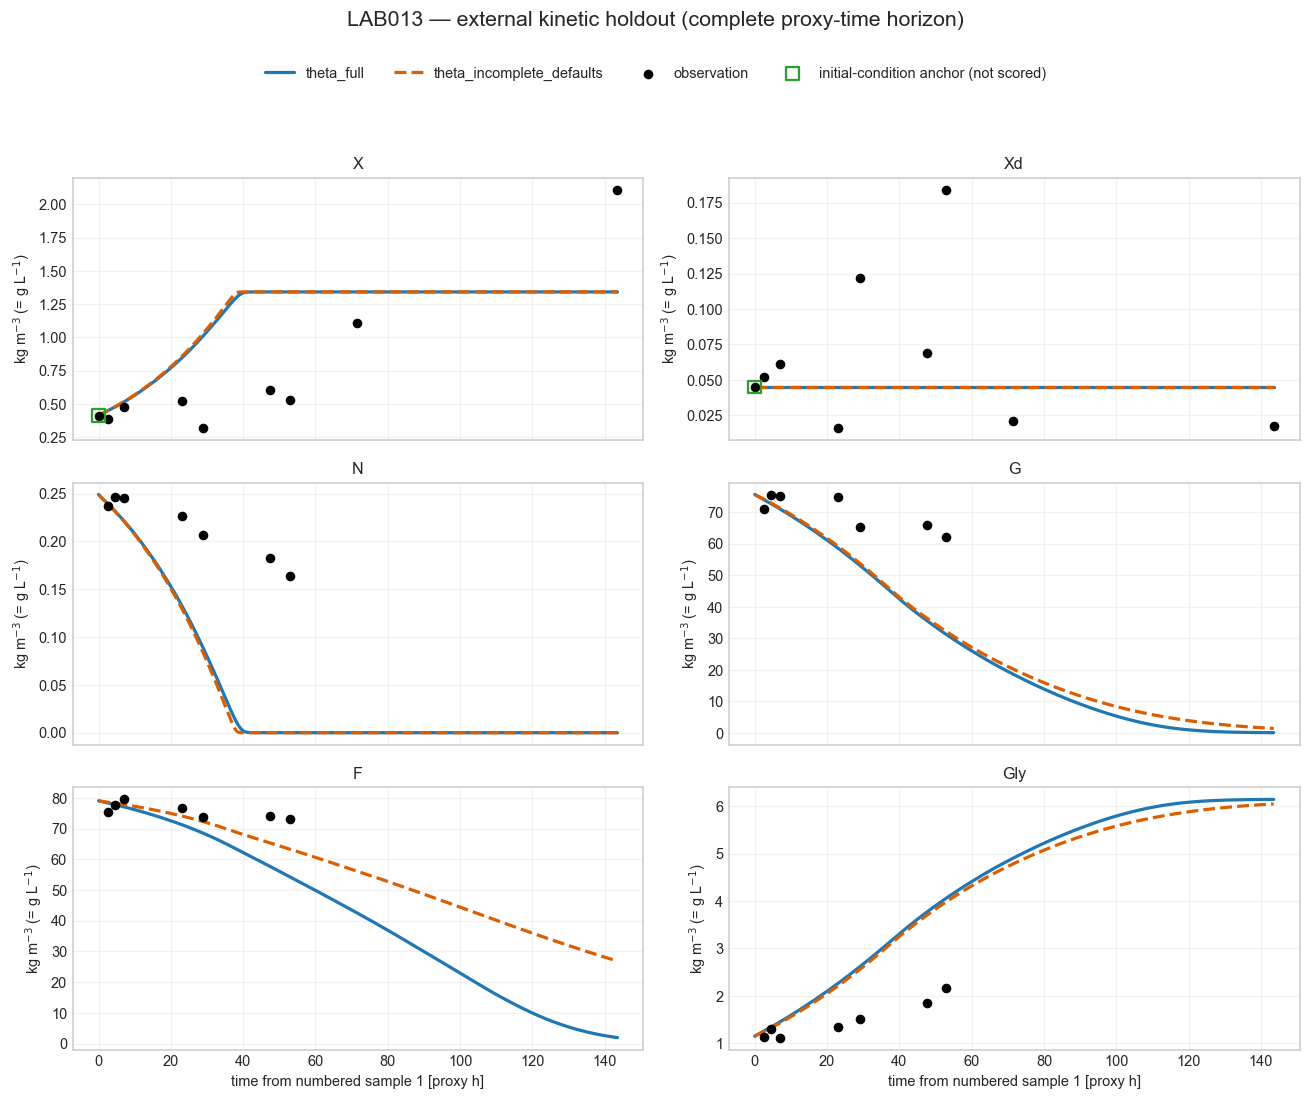

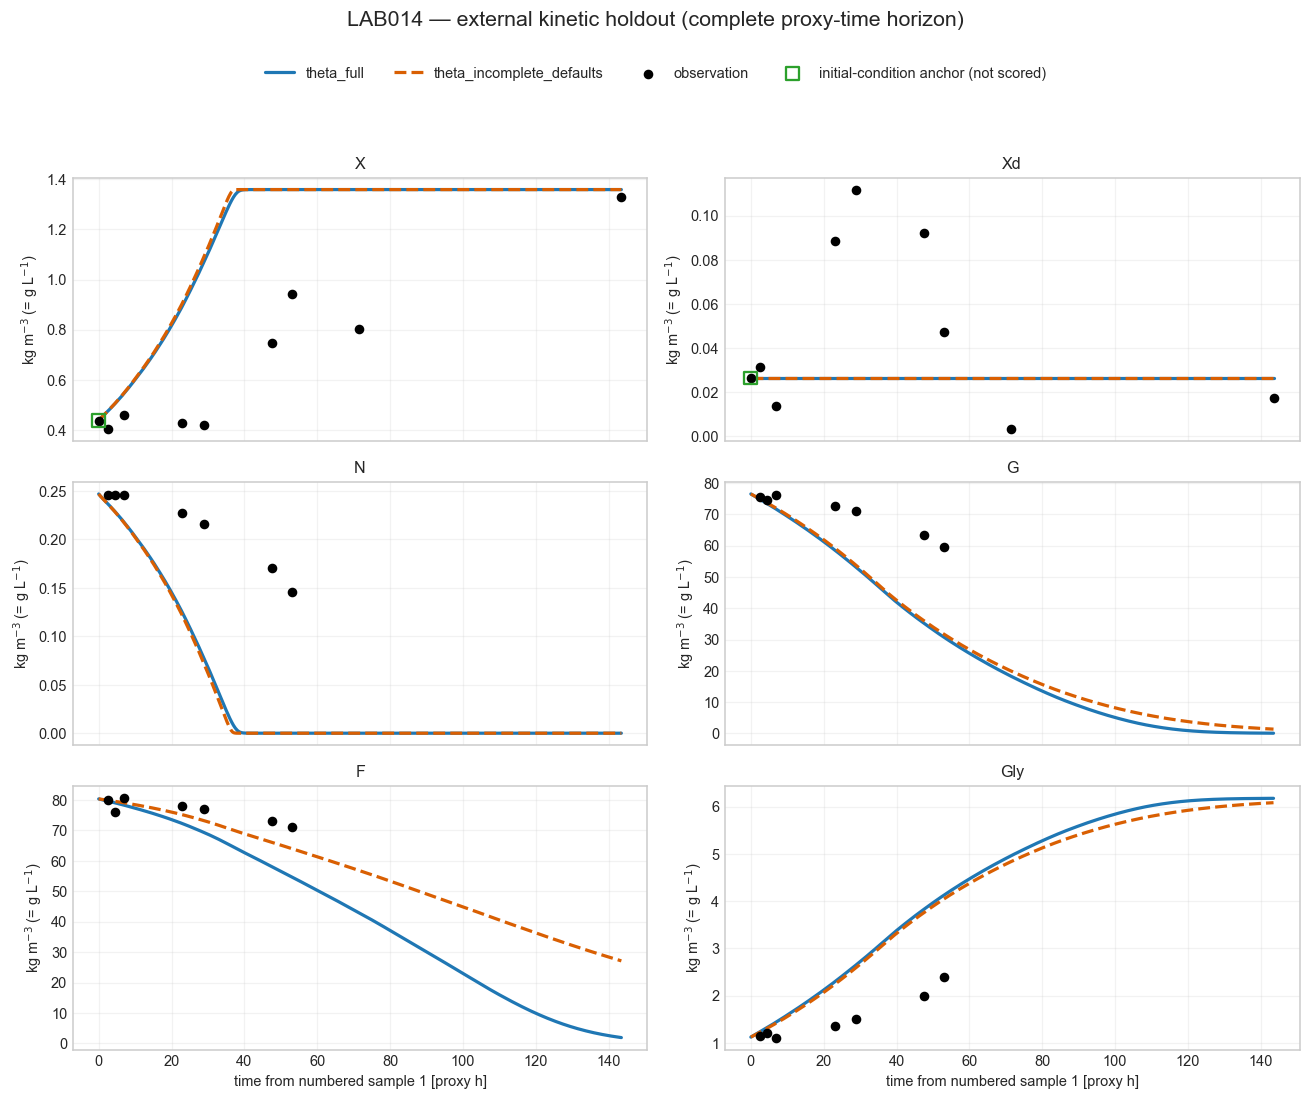

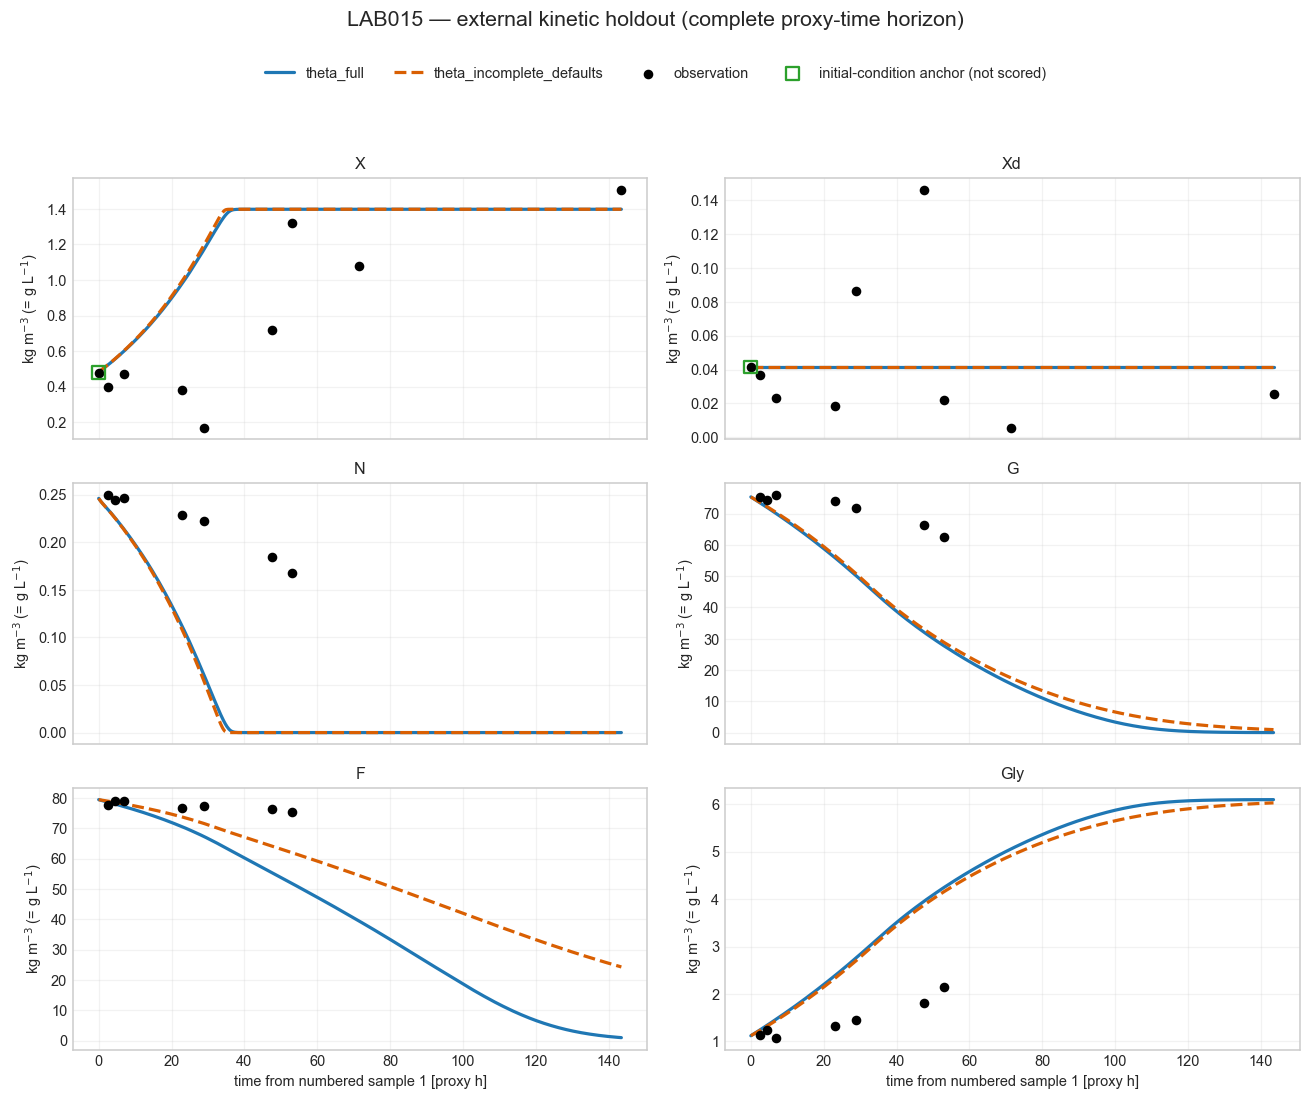

In [12]:
external_states = ("X", "Xd", "N", "G", "F", "Gly")
for batch in external_batches:
    fig, axes = plt.subplots(3, 2, figsize=(12.5, 10.2), sharex=True)
    for ax, state in zip(axes.flat, external_states):
        for theta_label in theta_sets:
            sim = holdout_trajectories[theta_label][batch.batch]
            ax.plot(sim.index, sim[state], color=COLORS[theta_label], ls=STYLES[theta_label],
                    lw=2.1, label=theta_label)
        obs = external_holdout_points[
            external_holdout_points["theta"].eq("theta_full")
            & external_holdout_points["batch"].eq(batch.batch)
            & external_holdout_points["state"].eq(state)
        ]
        ax.scatter(obs["time_h"], obs["observed"], color="black", s=28, zorder=4, label="observation")
        anchor = obs[obs["initial_condition_anchor"]]
        if not anchor.empty:
            ax.scatter(anchor["time_h"], anchor["observed"], marker="s", s=70, facecolors="none",
                       edgecolors="#2ca02c", linewidths=1.5, zorder=5, label="initial-condition anchor (not scored)")
        ax.set_title(state); ax.set_ylabel(STATE_UNITS[state]); ax.grid(alpha=0.25)
    axes[-1, 0].set_xlabel("time from numbered sample 1 [proxy h]")
    axes[-1, 1].set_xlabel("time from numbered sample 1 [proxy h]")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.suptitle(f"{batch.batch} — external kinetic holdout (complete proxy-time horizon)", y=0.995, fontsize=14)
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.957), ncol=4, frameon=False)
    fig.tight_layout(rect=(0.02, 0.02, 0.98, 0.91))
    fig.savefig(FIGURE_DIR / f"external_holdout_{batch.batch}.png", bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [13]:
dynamic_external = pd.concat([
    dynamic_features_for(external_batches, label, theta, "external holdout")
    for label, theta in theta_sets.items()
], ignore_index=True)
dynamic_features = pd.concat([dynamic_history, dynamic_external], ignore_index=True)
display(dynamic_external)

,scope,theta,batch,time_reference,horizon_h,X_max,X_max_time_h,X_plateau_h,X_plateau_status,Xd_max,...,G_t10_h,G_t10_status,F_t50_h,F_t50_status,F_t20_h,F_t20_status,F_t10_h,F_t10_status,termination_GplusF_le_4_h,termination_status
0,external holdout,theta_full,LAB013,proxy h from numbered sample 1; NOT absolute i...,143.5,1.341283,58.50,37.25,reached,0.044946,...,94.00,reached,76.25,reached,110.25,reached,124.00,reached,135.00,reached
1,external holdout,theta_full,LAB014,proxy h from numbered sample 1; NOT absolute i...,143.5,1.359164,56.75,35.75,reached,0.026495,...,93.00,reached,75.75,reached,110.00,reached,123.75,reached,134.75,reached
2,external holdout,theta_full,LAB015,proxy h from numbered sample 1; NOT absolute i...,143.5,1.398069,54.00,33.75,reached,0.041456,...,88.00,reached,71.25,reached,104.00,reached,117.25,reached,127.75,reached
3,external holdout,theta_incomplete_defaults,LAB013,proxy h from numbered sample 1; NOT absolute i...,143.5,1.341283,47.50,36.25,reached,0.044946,...,102.75,reached,111.50,reached,NaN,not reached,NaN,not reached,NaN,not reached
4,external holdout,theta_incomplete_defaults,LAB014,proxy h from numbered sample 1; NOT absolute i...,143.5,1.359164,45.75,34.75,reached,0.026495,...,102.00,reached,111.00,reached,NaN,not reached,NaN,not reached,NaN,not reached
5,external holdout,theta_incomplete_defaults,LAB015,proxy h from numbered sample 1; NOT absolute i...,143.5,1.398069,43.25,32.50,reached,0.041456,...,96.75,reached,105.25,reached,NaN,not reached,NaN,not reached,NaN,not reached


## One-at-a-time sensitivity from `theta_full`

Each variant replaces exactly one of the six inherited parameters by its
`theta_incomplete_defaults` value. No parameter is fitted. Impact is reported both as a
change in WSSE/weighted RMSE and as the RMS change in predicted observations measured in
historical-sigma units. The latter is also divided by the joint
`theta_full`→`theta_incomplete_defaults` trajectory change; because the model is nonlinear,
individual fractions need not sum to one.

In [14]:
def point_change_summary(reference_points, changed_points, group_columns):
    keys = ["batch", "state", "time_h"]
    ref = reference_points[keys + ["predicted", "sigma", "used_in_score"]].rename(
        columns={"predicted": "predicted_reference", "sigma": "sigma_reference", "used_in_score": "score_reference"}
    )
    changed = changed_points[keys + ["predicted", "used_in_score"]].rename(
        columns={"predicted": "predicted_changed", "used_in_score": "score_changed"}
    )
    merged = ref.merge(changed, on=keys, validate="one_to_one")
    merged = merged[merged["score_reference"] & merged["score_changed"]].copy()
    for column in group_columns:
        if column not in merged.columns:
            values = reference_points[column].dropna().unique()
            assert len(values) == 1, f"Cannot reconstruct grouping column {column}"
            merged[column] = values[0]
    merged["normalized_prediction_change"] = (
        merged["predicted_changed"] - merged["predicted_reference"]
    ) / merged["sigma_reference"]
    rows = []
    for grouping, group in merged.groupby(group_columns, sort=True):
        grouping = grouping if isinstance(grouping, tuple) else (grouping,)
        row = {name: value for name, value in zip(group_columns, grouping)}
        row.update({
            "n_prediction_points": len(group),
            "trajectory_change_rms_sigma": float(np.sqrt(np.mean(group["normalized_prediction_change"] ** 2))),
            "trajectory_change_max_abs_sigma": float(np.max(np.abs(group["normalized_prediction_change"]))),
        })
        rows.append(row)
    return pd.DataFrame(rows)

replay_full_points = calibration_replay_points[calibration_replay_points["theta"].eq("theta_full")]
replay_joint_points = calibration_replay_points[calibration_replay_points["theta"].eq("theta_incomplete_defaults")]
holdout_full_points = external_holdout_points[external_holdout_points["theta"].eq("theta_full")]
holdout_joint_points = external_holdout_points[external_holdout_points["theta"].eq("theta_incomplete_defaults")]

joint_change_by_scope_state = {}
for scope, ref, changed in (
    ("historical calibration replay", replay_full_points, replay_joint_points),
    ("external holdout", holdout_full_points, holdout_joint_points),
):
    by_state = point_change_summary(ref, changed, ["state"])
    global_change = point_change_summary(
        ref.assign(global_group="GLOBAL"), changed.assign(global_group="GLOBAL"), ["global_group"]
    )
    joint_change_by_scope_state[scope] = {
        **by_state.set_index("state")["trajectory_change_rms_sigma"].to_dict(),
        "GLOBAL": float(global_change["trajectory_change_rms_sigma"].iloc[0]),
    }

oat_rows, oat_dynamic_frames = [], []
full_dynamic_lookup = {
    "historical calibration replay": dynamic_history[dynamic_history["theta"].eq("theta_full")],
    "external holdout": dynamic_external[dynamic_external["theta"].eq("theta_full")],
}
for parameter in inherited:
    variant_label = f"theta_full_with_{parameter}_from_theta_incomplete_defaults"
    variant = dict(theta_full)
    variant[parameter] = theta_incomplete_defaults[parameter]
    assert {
        name for name in kinetic.FULL17 if not np.isclose(variant[name], theta_full[name], rtol=0, atol=1e-15)
    } == {parameter}

    replay_variant, _ = prediction_points(
        historical_batches, variant_label, variant, "historical calibration replay", True
    )
    holdout_variant, _ = external_points_for_theta(variant_label, variant)
    for scope, ref_points, variant_points in (
        ("historical calibration replay", replay_full_points, replay_variant),
        ("external holdout", holdout_full_points, holdout_variant),
    ):
        state_metrics = metrics_by_group(variant_points, ["state"], endpoints=False)
        state_change = point_change_summary(ref_points, variant_points, ["state"]).set_index("state")
        full_state_metrics = metrics_by_group(ref_points, ["state"], endpoints=False).set_index("state")
        for row in state_metrics.itertuples(index=False):
            state = row.state
            change_rms = float(state_change.loc[state, "trajectory_change_rms_sigma"])
            joint_rms = joint_change_by_scope_state[scope][state]
            oat_rows.append({
                "parameter": parameter, "variant": variant_label, "scope": scope, "level": "state", "state": state,
                "theta_full_value": theta_full[parameter], "replacement_value": theta_incomplete_defaults[parameter],
                "n_observations": row.n_observations, "wsse": row.wsse,
                "weighted_rmse_sigma_units": row.weighted_rmse_sigma_units,
                "delta_wsse_vs_theta_full": row.wsse - full_state_metrics.loc[state, "wsse"],
                "trajectory_change_rms_sigma": change_rms,
                "joint_six_parameter_change_rms_sigma": joint_rms,
                "fraction_of_joint_trajectory_change": change_rms / joint_rms if joint_rms > 0 else np.nan,
            })
        variant_global = normalized_aggregate(variant_points.assign(global_group="GLOBAL"), ["global_group"]).iloc[0]
        full_global = normalized_aggregate(ref_points.assign(global_group="GLOBAL"), ["global_group"]).iloc[0]
        global_change = point_change_summary(
            ref_points.assign(global_group="GLOBAL"), variant_points.assign(global_group="GLOBAL"), ["global_group"]
        ).iloc[0]
        joint_global = joint_change_by_scope_state[scope]["GLOBAL"]
        oat_rows.append({
            "parameter": parameter, "variant": variant_label, "scope": scope, "level": "global", "state": "GLOBAL",
            "theta_full_value": theta_full[parameter], "replacement_value": theta_incomplete_defaults[parameter],
            "n_observations": variant_global.n_observations, "wsse": variant_global.wsse,
            "weighted_rmse_sigma_units": variant_global.weighted_rmse_sigma_units,
            "delta_wsse_vs_theta_full": variant_global.wsse - full_global.wsse,
            "trajectory_change_rms_sigma": global_change.trajectory_change_rms_sigma,
            "joint_six_parameter_change_rms_sigma": joint_global,
            "fraction_of_joint_trajectory_change": global_change.trajectory_change_rms_sigma / joint_global if joint_global > 0 else np.nan,
        })

    for scope, batches in (("historical calibration replay", historical_batches), ("external holdout", external_batches)):
        variant_dynamic = dynamic_features_for(batches, variant_label, variant, scope)
        ref_dynamic = full_dynamic_lookup[scope].copy()
        merged = variant_dynamic.merge(ref_dynamic, on=["scope", "batch"], suffixes=("", "_theta_full"), validate="one_to_one")
        for feature in (
            "X_max", "X_plateau_h", "N_t50_h", "N_t20_h", "N_t10_h",
            "G_t50_h", "G_t20_h", "G_t10_h", "F_t50_h", "F_t20_h", "F_t10_h",
            "Gly_final", "E_final", "termination_GplusF_le_4_h",
        ):
            merged[f"delta_{feature}_vs_theta_full"] = merged[feature] - merged[f"{feature}_theta_full"]
        merged["parameter_replaced"] = parameter
        merged["theta_full_value"] = theta_full[parameter]
        merged["replacement_value"] = theta_incomplete_defaults[parameter]
        oat_dynamic_frames.append(merged)

one_at_a_time_sensitivity = pd.DataFrame(oat_rows)
one_at_a_time_dynamic_features = pd.concat(oat_dynamic_frames, ignore_index=True)
display(one_at_a_time_sensitivity[one_at_a_time_sensitivity["level"].eq("global")].sort_values(
    ["scope", "trajectory_change_rms_sigma"], ascending=[True, False]
))

,parameter,variant,scope,level,state,theta_full_value,replacement_value,n_observations,wsse,weighted_rmse_sigma_units,delta_wsse_vs_theta_full,trajectory_change_rms_sigma,joint_six_parameter_change_rms_sigma,fraction_of_joint_trajectory_change
74,sF,theta_full_with_sF_from_theta_incomplete_defaults,external holdout,global,GLOBAL,0.178295,0.0300,132,4587.642392,5.895326,10.491669,0.893684,0.827812,1.079573
59,sG,theta_full_with_sG_from_theta_incomplete_defaults,external holdout,global,GLOBAL,0.097455,0.0300,132,4198.262579,5.639594,-378.888144,0.445021,0.827812,0.537587
14,sN,theta_full_with_sN_from_theta_incomplete_defaults,external holdout,global,GLOBAL,8.751446,18.0000,132,4675.235042,5.951340,98.084319,0.092880,0.827812,0.112200
44,qXF,theta_full_with_qXF_from_theta_incomplete_defa...,external holdout,global,GLOBAL,0.070933,0.1125,132,4598.396515,5.902232,21.245792,0.047316,0.827812,0.057158
29,qXG,theta_full_with_qXG_from_theta_incomplete_defa...,external holdout,global,GLOBAL,0.081491,0.1125,132,4607.199142,5.907878,30.048418,0.034843,0.827812,0.042090
89,m0,theta_full_with_m0_from_theta_incomplete_defaults,external holdout,global,GLOBAL,0.018339,0.0100,132,4559.438654,5.877176,-17.712070,0.022085,0.827812,0.026679
67,sF,theta_full_with_sF_from_theta_incomplete_defaults,historical calibration replay,global,GLOBAL,0.178295,0.0300,608,15706.184837,5.082572,4034.100017,2.422847,2.869971,0.844206
52,sG,theta_full_with_sG_from_theta_incomplete_defaults,historical calibration replay,global,GLOBAL,0.097455,0.0300,608,12374.187252,4.511350,702.102432,0.987119,2.869971,0.343947
7,sN,theta_full_with_sN_from_theta_incomplete_defaults,historical calibration replay,global,GLOBAL,8.751446,18.0000,608,11710.095837,4.388625,38.011018,0.115387,2.869971,0.040205
82,m0,theta_full_with_m0_from_theta_incomplete_defaults,historical calibration replay,global,GLOBAL,0.018339,0.0100,608,11677.316089,4.382478,5.231270,0.080219,2.869971,0.027951


In [15]:
tables_to_save = {
    "parameter_provenance.csv": parameter_provenance,
    "parameters_comparison.csv": parameters_comparison,
    "historical_input_audit.csv": historical_input_audit,
    "calibration_replay_metrics_by_state_batch.csv": calibration_replay_metrics_by_state_batch,
    "calibration_replay_metrics_by_state.csv": calibration_replay_metrics_by_state,
    "calibration_replay_metrics_by_batch.csv": calibration_replay_metrics_by_batch,
    "calibration_replay_metrics_global.csv": calibration_replay_metrics_global,
    "calibration_replay_point_predictions.csv": calibration_replay_points,
    "calibration_replay_trajectory_differences.csv": calibration_replay_trajectory_differences,
    "external_holdout_source_audit.csv": external_source_audit,
    "external_holdout_initial_conditions.csv": external_initial_conditions,
    "external_holdout_metrics_by_state_batch.csv": external_holdout_metrics_by_state_batch,
    "external_holdout_metrics_by_state.csv": external_holdout_metrics_by_state,
    "external_holdout_metrics_global.csv": external_holdout_metrics_global,
    "external_holdout_point_predictions.csv": external_holdout_points,
    "dynamic_features.csv": dynamic_features,
    "one_at_a_time_sensitivity.csv": one_at_a_time_sensitivity,
    "one_at_a_time_dynamic_features.csv": one_at_a_time_dynamic_features,
}
for filename, frame in tables_to_save.items():
    frame.to_csv(RESULTS_DIR / filename, index=False)

replay_global = calibration_replay_metrics_global.set_index("theta")
holdout_global = external_holdout_metrics_global.set_index("theta")
replay_winner = replay_global["weighted_rmse_sigma_units"].idxmin()
holdout_winner = holdout_global["weighted_rmse_sigma_units"].idxmin()

replay_state_pivot = calibration_replay_metrics_by_state.pivot(index="state", columns="theta", values="weighted_rmse_sigma_units")
replay_state_pivot["abs_change"] = (
    replay_state_pivot["theta_incomplete_defaults"] - replay_state_pivot["theta_full"]
).abs()
holdout_state_pivot = external_holdout_metrics_by_state.pivot(index="state", columns="theta", values="weighted_rmse_sigma_units")
holdout_state_pivot["abs_change"] = (
    holdout_state_pivot["theta_incomplete_defaults"] - holdout_state_pivot["theta_full"]
).abs()
replay_states_most_changed = replay_state_pivot.sort_values("abs_change", ascending=False).head(3).index.tolist()
holdout_states_most_changed = holdout_state_pivot.sort_values("abs_change", ascending=False).head(3).index.tolist()

replay_batch_pivot = calibration_replay_metrics_by_batch.pivot(index="batch", columns="theta", values="weighted_rmse_sigma_units")
replay_batch_pivot["abs_change"] = (
    replay_batch_pivot["theta_incomplete_defaults"] - replay_batch_pivot["theta_full"]
).abs()
replay_batches_most_changed = replay_batch_pivot.sort_values("abs_change", ascending=False).head(3).index.tolist()

oat_global = one_at_a_time_sensitivity[one_at_a_time_sensitivity["level"].eq("global")]
oat_rankings = {
    scope: group.sort_values("trajectory_change_rms_sigma", ascending=False)["parameter"].tolist()
    for scope, group in oat_global.groupby("scope")
}
conclusion_summary = {
    "historical_replay_is_holdout": False,
    "historical_labs": list(expected_historical_labs),
    "external_holdout_labs": list(EXTERNAL_LABS),
    "replay_weighted_rmse": replay_global["weighted_rmse_sigma_units"].to_dict(),
    "external_weighted_rmse": holdout_global["weighted_rmse_sigma_units"].to_dict(),
    "replay_lower_error_theta": replay_winner,
    "external_lower_error_theta": holdout_winner,
    "replay_states_most_changed": replay_states_most_changed,
    "external_states_most_changed": holdout_states_most_changed,
    "replay_batches_most_changed": replay_batches_most_changed,
    "oat_parameter_ranking": oat_rankings,
    "time_limitation": "LAB013–LAB015 use proxy hours from numbered sample 1, not absolute time since inoculation",
    "optimization_executed": False,
}
(RESULTS_DIR / "conclusions_summary.json").write_text(
    json.dumps(conclusion_summary, indent=2, ensure_ascii=False), encoding="utf-8"
)

display(Markdown(f'''
## Conclusions

### A. Historical calibration replay

- This is **in-sample calibration replay, not an external holdout**. LAB004–LAB012,
  including LAB009, were used in the historical natural kinetic calibration.
- Weighted RMSE (historical-sigma units): `theta_full` =
  **{replay_global.loc['theta_full', 'weighted_rmse_sigma_units']:.4g}**;
  `theta_incomplete_defaults` =
  **{replay_global.loc['theta_incomplete_defaults', 'weighted_rmse_sigma_units']:.4g}**.
  Lower replay error: **{replay_winner}**.
- States with the largest absolute weighted-RMSE change: **{', '.join(replay_states_most_changed)}**.
- Batches with the largest absolute weighted-RMSE change: **{', '.join(replay_batches_most_changed)}**.
- OAT trajectory-impact ranking: **{' > '.join(oat_rankings['historical calibration replay'])}**.

### B. External holdout — LAB013–LAB015

- Weighted RMSE (historical-sigma units): `theta_full` =
  **{holdout_global.loc['theta_full', 'weighted_rmse_sigma_units']:.4g}**;
  `theta_incomplete_defaults` =
  **{holdout_global.loc['theta_incomplete_defaults', 'weighted_rmse_sigma_units']:.4g}**.
  Better transfer under this aggregate metric: **{holdout_winner}**.
- Holdout states with the largest absolute weighted-RMSE change:
  **{', '.join(holdout_states_most_changed)}**.
- OAT trajectory-impact ranking: **{' > '.join(oat_rankings['external holdout'])}**.
- Generalization conclusions come only from LAB013–LAB015; LAB016–LAB018 are absent.

### Provenance and limitations

- The six full-vector values come from `multistart_07` and were fixed during the natural
  re-estimation. The incomplete values are literature-supported defaults, but inserting
  them after calibration creates a vector inconsistent with that calibration.
- Zenteno prints `m0=0.01` directly. The other five default values are verified algebraic
  reparameterizations of values printed in its equations/Table 2, with matching units.
- LAB013–LAB015 times are proxy hours from numbered sample 1; absolute timing from
  inoculation, absolute onset and absolute termination age remain unresolved.
- X/Xd at proxy time zero initialize the external simulations and are shown but excluded
  from holdout scores. E is unscored because no valid temporal series is available.
- No fitting, optimization, CO2 pool/release, chemical gate, O2 layer or matrix gain was executed.
'''))


## Conclusions

### A. Historical calibration replay

- This is **in-sample calibration replay, not an external holdout**. LAB004–LAB012,
  including LAB009, were used in the historical natural kinetic calibration.
- Weighted RMSE (historical-sigma units): `theta_full` =
  **4.381**;
  `theta_incomplete_defaults` =
  **5.326**.
  Lower replay error: **theta_full**.
- States with the largest absolute weighted-RMSE change: **F, E, G**.
- Batches with the largest absolute weighted-RMSE change: **LAB007, LAB008, LAB005**.
- OAT trajectory-impact ranking: **sF > sG > sN > m0 > qXF > qXG**.

### B. External holdout — LAB013–LAB015

- Weighted RMSE (historical-sigma units): `theta_full` =
  **5.889**;
  `theta_incomplete_defaults` =
  **5.685**.
  Better transfer under this aggregate metric: **theta_incomplete_defaults**.
- Holdout states with the largest absolute weighted-RMSE change:
  **F, G, Gly**.
- OAT trajectory-impact ranking: **sF > sG > sN > qXF > qXG > m0**.
- Generalization conclusions come only from LAB013–LAB015; LAB016–LAB018 are absent.

### Provenance and limitations

- The six full-vector values come from `multistart_07` and were fixed during the natural
  re-estimation. The incomplete values are literature-supported defaults, but inserting
  them after calibration creates a vector inconsistent with that calibration.
- Zenteno prints `m0=0.01` directly. The other five default values are verified algebraic
  reparameterizations of values printed in its equations/Table 2, with matching units.
- LAB013–LAB015 times are proxy hours from numbered sample 1; absolute timing from
  inoculation, absolute onset and absolute termination age remain unresolved.
- X/Xd at proxy time zero initialize the external simulations and are shown but excluded
  from holdout scores. E is unscored because no valid temporal series is available.
- No fitting, optimization, CO2 pool/release, chemical gate, O2 layer or matrix gain was executed.


In [16]:
required_outputs = [
    "parameter_provenance.csv", "parameters_comparison.csv",
    "calibration_replay_metrics_by_state_batch.csv", "calibration_replay_metrics_by_state.csv",
    "calibration_replay_metrics_by_batch.csv", "calibration_replay_metrics_global.csv",
    "external_holdout_metrics_by_state_batch.csv", "external_holdout_metrics_by_state.csv",
    "external_holdout_metrics_global.csv", "dynamic_features.csv", "one_at_a_time_sensitivity.csv",
]
assert all((RESULTS_DIR / name).exists() for name in required_outputs)
assert set(calibration_replay_metrics_by_state_batch["batch"]) == set(expected_historical_labs)
assert set(external_holdout_metrics_by_state_batch["batch"]) == set(EXTERNAL_LABS)
assert set(parameters_comparison.loc[parameters_comparison["differs"], "parameter"]) == set(inherited)
assert set(theta_sets) == {"theta_full", "theta_incomplete_defaults"}
assert not any(token in globals() for token in ("chemical_gate", "matrix_gain", "CO2_pool"))
print(f"Saved {len(tables_to_save)} CSV tables and {len(list(FIGURE_DIR.glob('*.png')))} figures.")
print("Notebook safeguards passed: frozen theta only; zero optimization; LAB004–012 replay separate from LAB013–LAB015 holdout.")

Saved 18 CSV tables and 19 figures.
Notebook safeguards passed: frozen theta only; zero optimization; LAB004–012 replay separate from LAB013–LAB015 holdout.
